# Dark-matter quantum-sensor response analysis

Forward + inverse analysis of the detector response, organised **by detector**
and, within each, **by velocity-distribution model**. Same pipeline throughout
(load Mathematica response matrix -> forward model `exposure * M @ eta` ->
recover the monotone non-negative flux `x(v_min)`); only two things change:

- **detector** (`material`): **TES (Al)** -- Mermin, 0.1 eV threshold, fine `R10`;
  **MKID (TiN)** -- Lindhard, 0.2 eV threshold, fine `R9`.
- **velocity model**: **Halo** -- standard halo (SHM, `v0=238, ve=250, vesc=544`
  km/s); **pure dark disk** -- same DM density, colder (`v0=70, ve=100,
  vesc=694`). The actual **best-fit uses a mixture** `eta = (1-p)*Halo + p*Disk`
  with disk fraction `p`; because both components carry the same local DM
  density, the mixture's density equals 100% SHM for any `p`. A third model,
  **Bound** (Earth-captured thermal DM), is a separate dense population
  (`rho_b`, isotropic, `vesc=11.2` km/s) -- only the heaviest mass (1 GeV) has
  any signal, since the bound DM is too slow to reach higher `v_min`.

The mixture sections sweep `p` over `DISK_FRACTIONS` and overlay, on each fit,
the **100% SHM** halo and the **`p` x pure disk** component for reference.


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from quantum_sensor import DarkMatterQuantumAnalysis, RunConfig

MASS_LABELS = {'1': '10 MeV', '2': '100 MeV', '3': '1 GeV'}
DETECTOR = {'Al': 'TES', 'TiN': 'MKID'}
# Dark-disk mixing fractions p for the best-fit eta = (1-p)*Halo + p*Disk.
DISK_FRACTIONS = (0.05, 0.25)


def run_masses(material, q='0', nbins=5, eta='Halo', background='none',
               disk_fraction=None, masses=('1', '2', '3'), solver='osqp', save=True):
    """Run the forward+inverse analysis for several DM masses.

    Shows one combined figure (the masses side by side). When ``save=True``
    (default) each run is ALSO saved on its own -- flux.csv plus an individual
    flux.pdf -- into its per-run folder
    results/<DET>/bkg-<background>/<material>_q<q>_M<mass>_R<nbins>_<eta>/, so
    every type is stored separately regardless of the combined display.
    """
    fig, axes = plt.subplots(1, len(masses), figsize=(6 * len(masses), 5), squeeze=False)
    for ax, mass in zip(axes[0], masses):
        a = DarkMatterQuantumAnalysis(
            RunConfig(material=material, q=q, mass=mass, nbins=nbins,
                      eta=eta, disk_fraction=disk_fraction, background=background))
        flux = a.optimize(solver=solver)
        print('signal     :', a.signal)
        print('background :', a.background)

        if save:
            a.save_flux()                     # flux.csv in this run's own folder
            sfig, sax = plt.subplots(figsize=(8, 6))
            a.plot(save=True, ax=sax)         # individual flux.pdf next to the CSV
            plt.close(sfig)                   # keep only the combined figure on screen

        a.plot(save=False, ax=ax)             # combined panel (display only)
        ax.set_title(f'{material} ({DETECTOR[material]}), $m_\\chi$ = {MASS_LABELS[mass]}',
                     fontsize=13)
        print(f'{material} q{q} M{mass} R{nbins}: {a.n_ebins} E-bins x '
              f'{a.n_vmin} v_min bins, peak flux {flux.max():.2e}')
    model = eta if disk_fraction is None else f'mix {round(disk_fraction*100)}% disk'
    fig.suptitle(f'{material} ({DETECTOR[material]}), q{q}, R{nbins}, {model}, bkg={background}',
                 fontsize=14)
    plt.tight_layout(); plt.show()


# TES (Al)

## Halo (SHM) — reference

### Heavy mediator (q0), 5 energy bins

signal     : [ 705.55175893 1378.01639166 2073.97204148 2822.89736877 3443.58224531]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M1_R5_Halo/flux.pdf
Al q0 M1 R5: 5 E-bins x 65 v_min bins, peak flux 7.71e+02
signal     : [ 75.04064212 152.5696063  224.8560444  282.99026892 337.02974027]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R5_Halo/flux.pdf
Al q0 M2 R5: 5 E-bins x 53 v_min bins, peak flux 8.25e+01
signal     : [ 7.68835856 14.40117892 21.20924145 27.84555407 34.70818753]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M3_R5_Halo/flux.pdf
Al q0 M3 R5: 5 E-bins x 47 v_min bins, peak flux 8.28e+00


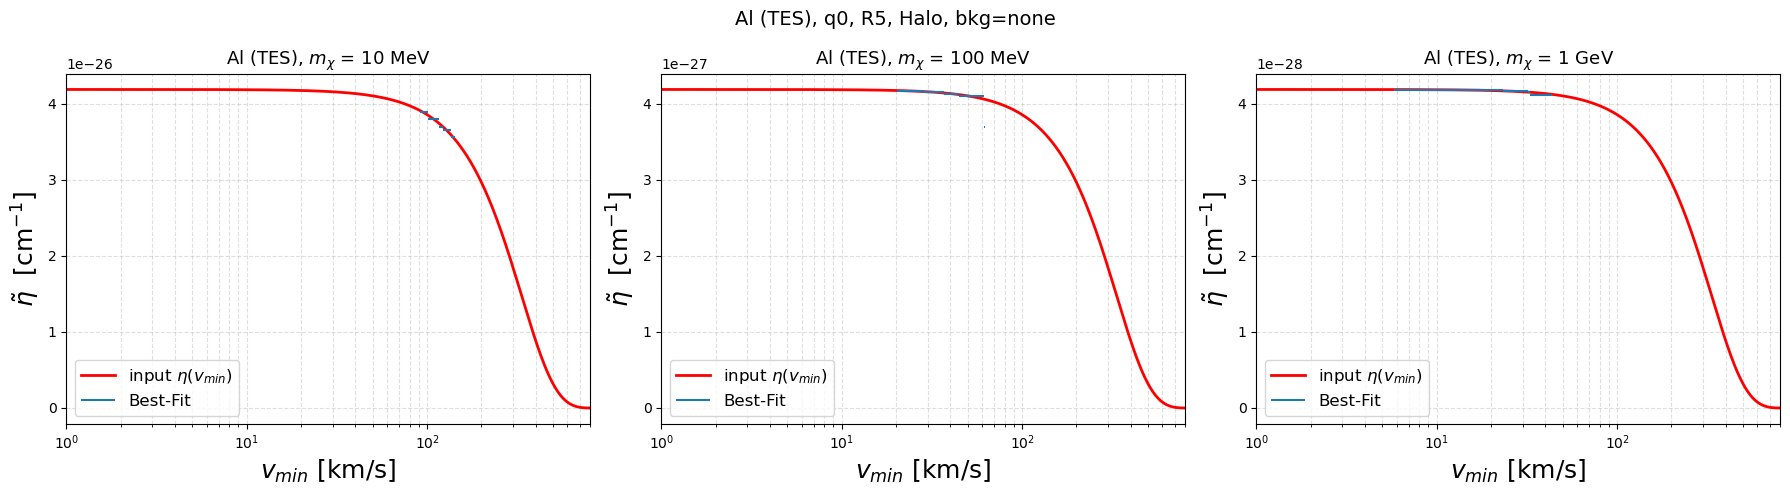

In [2]:
run_masses('Al', q='0', nbins=5, eta='Halo', solver = 'scipy')

### Light mediator (q2), 5 energy bins

signal     : [ 701.71166434 1339.19392089 1857.48247376 2336.0821546  2801.79904526]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M1_R5_Halo/flux.pdf
Al q2 M1 R5: 5 E-bins x 106 v_min bins, peak flux 7.95e+02
signal     : [ 65.20738314 126.62366456 181.71362873 232.99713822 281.0981104 ]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M2_R5_Halo/flux.pdf
Al q2 M2 R5: 5 E-bins x 115 v_min bins, peak flux 8.25e+01
signal     : [ 6.42627095 12.65534704 18.00177244 23.06227726 27.83964852]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M3_R5_Halo/flux.pdf
Al q2 M3 R5: 5 E-bins x 119 v_min bins, peak flux 8.26e+00


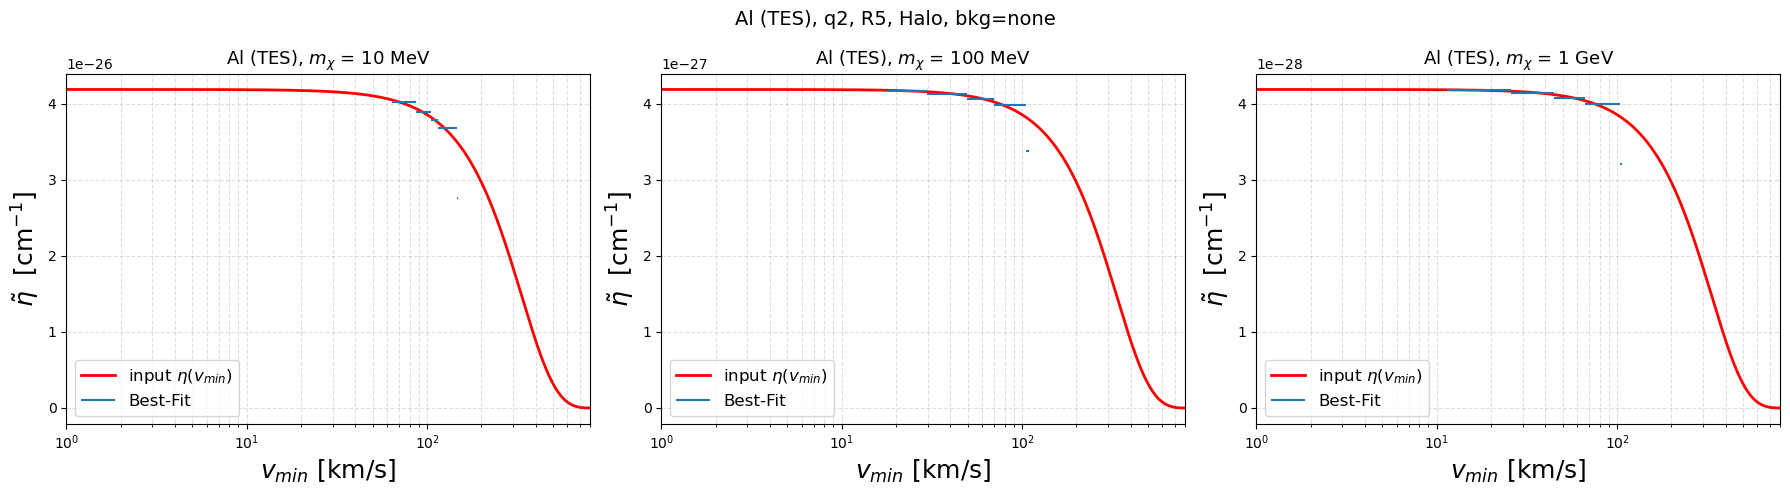

In [3]:
run_masses('Al', q='2', nbins=5, eta='Halo', solver = 'scipy')

### Heavy mediator (q0), 10 energy bins

signal     : [ 271.42713167  463.29652837  650.6554393   806.03934089  989.3720153
 1199.24391679 1378.20697148 1507.7940619  1709.66281933 1863.56207081]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M1_R10_Halo/flux.pdf
Al q0 M1 R10: 10 E-bins x 69 v_min bins, peak flux 7.74e+02
signal     : [ 33.08421199  57.27490073  70.59105817  95.79088015 101.6034004
 124.01151148 137.44797898 150.55688178 180.09091459 189.28976275]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R10_Halo/flux.pdf
Al q0 M2 R10: 10 E-bins x 60 v_min bins, peak flux 8.27e+01
signal     : [ 2.79806476  4.86755104  6.26888105  8.46539719  9.90728492 12.00457053
 13.38073492 15.52925955 17.07958916 18.66211884]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/Quantum

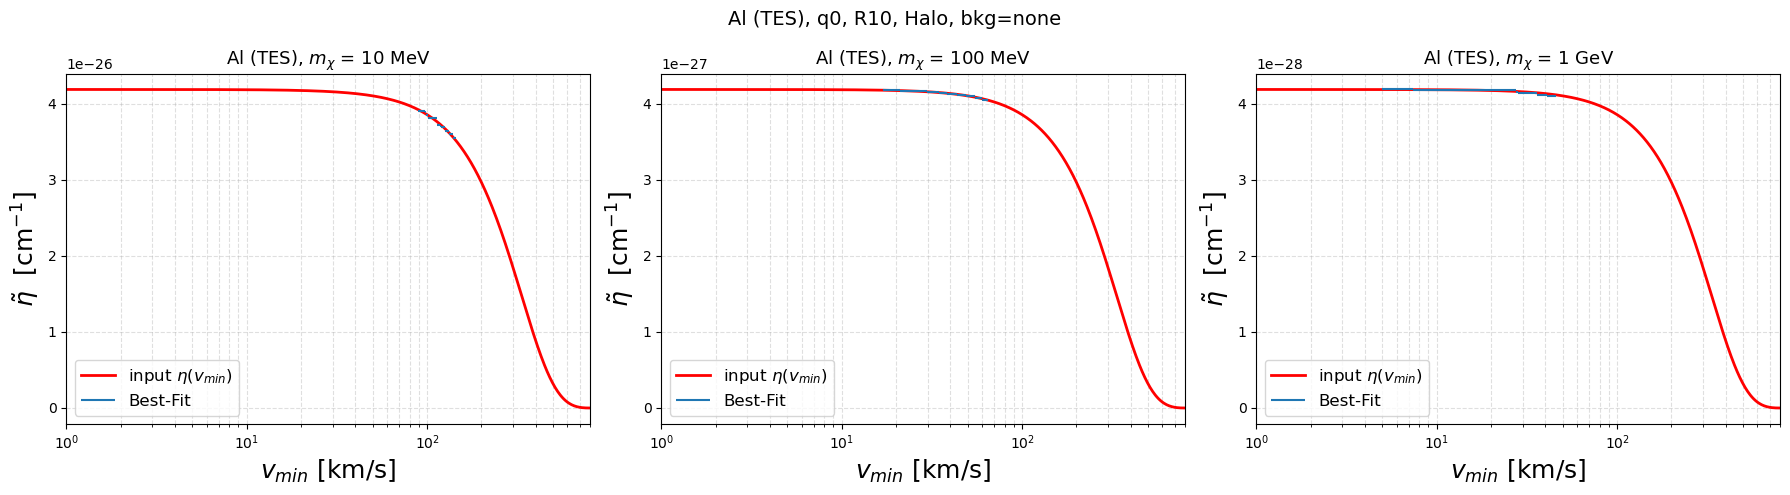

In [4]:
run_masses('Al', q='0', nbins=10, eta='Halo', solver = 'scipy')

### Light mediator (q2), 10 energy bins

signal     : [ 274.38396617  456.74605352  603.08438102  776.21638899  927.46483556
 1061.05197834 1182.88264776 1276.9713486  1398.19066222 1501.27835637]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M1_R10_Halo/flux.pdf
Al q2 M1 R10: 10 E-bins x 122 v_min bins, peak flux 8.06e+02
signal     : [ 26.17444676  43.09089032  59.21429952  74.61206763  87.43602665
 102.0148561  116.04922283 127.94328334 141.42904182 152.53426307]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M2_R10_Halo/flux.pdf
Al q2 M2 R10: 10 E-bins x 122 v_min bins, peak flux 8.26e+01
signal     : [ 2.58936312  4.27740035  5.79557203  7.29477219  8.75367084 10.19673094
 11.59197828 12.77569142 13.95155374 15.24863859]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/Qua

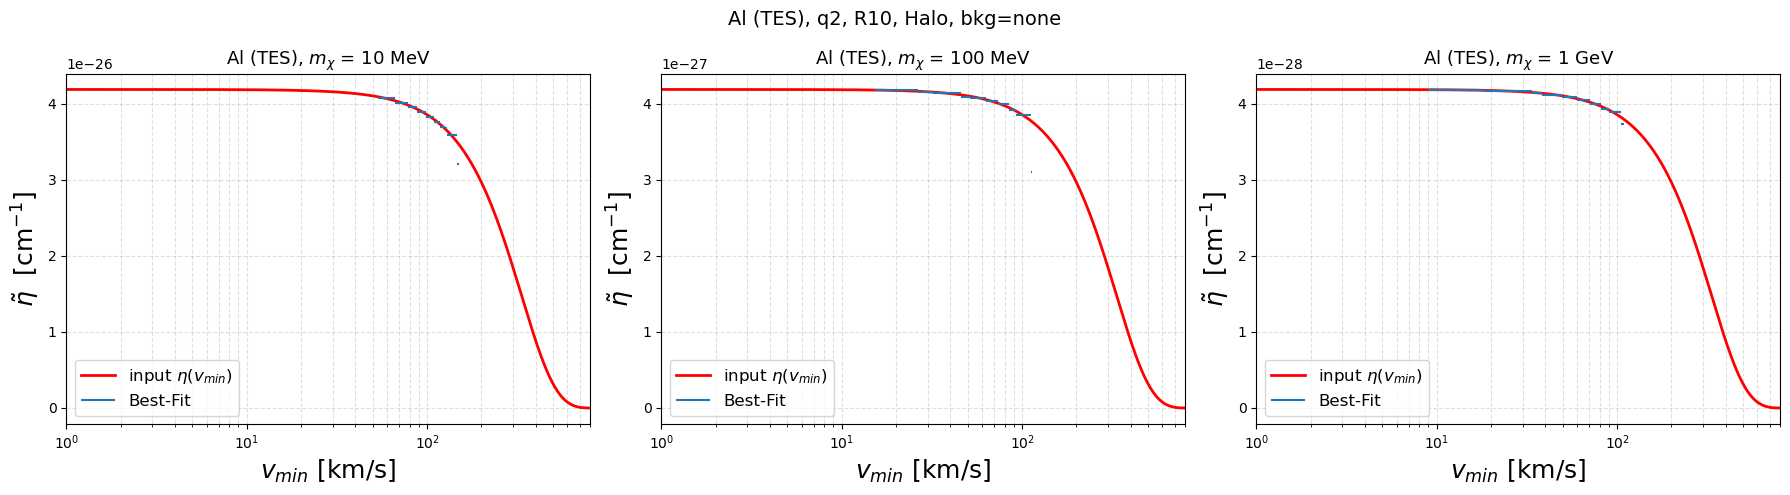

In [5]:
run_masses('Al', q='2', nbins=10, eta='Halo', solver = 'scipy')

## Mixture (best-fit) — sweep dark-disk fraction

`eta = (1-p)*Halo + p*Disk`. Each figure overlays 100% SHM (gray) and `p` x pure disk (green).

### Heavy mediator (q0), 5 energy bins

signal     : [ 725.43819227 1402.74360633 2094.93882584 2815.83542611 3394.66437224]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M1_R5_mix5/flux.pdf
Al q0 M1 R5: 5 E-bins x 65 v_min bins, peak flux 7.98e+02
signal     : [ 81.41909127 165.17467061 242.62040554 304.05643753 360.02380247]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R5_mix5/flux.pdf
Al q0 M2 R5: 5 E-bins x 53 v_min bins, peak flux 8.96e+01
signal     : [ 8.3592685  15.65277487 23.03962331 30.22547655 37.6379469 ]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M3_R5_mix5/flux.pdf
Al q0 M3 R5: 5 E-bins x 47 v_min bins, peak flux 9.01e+00


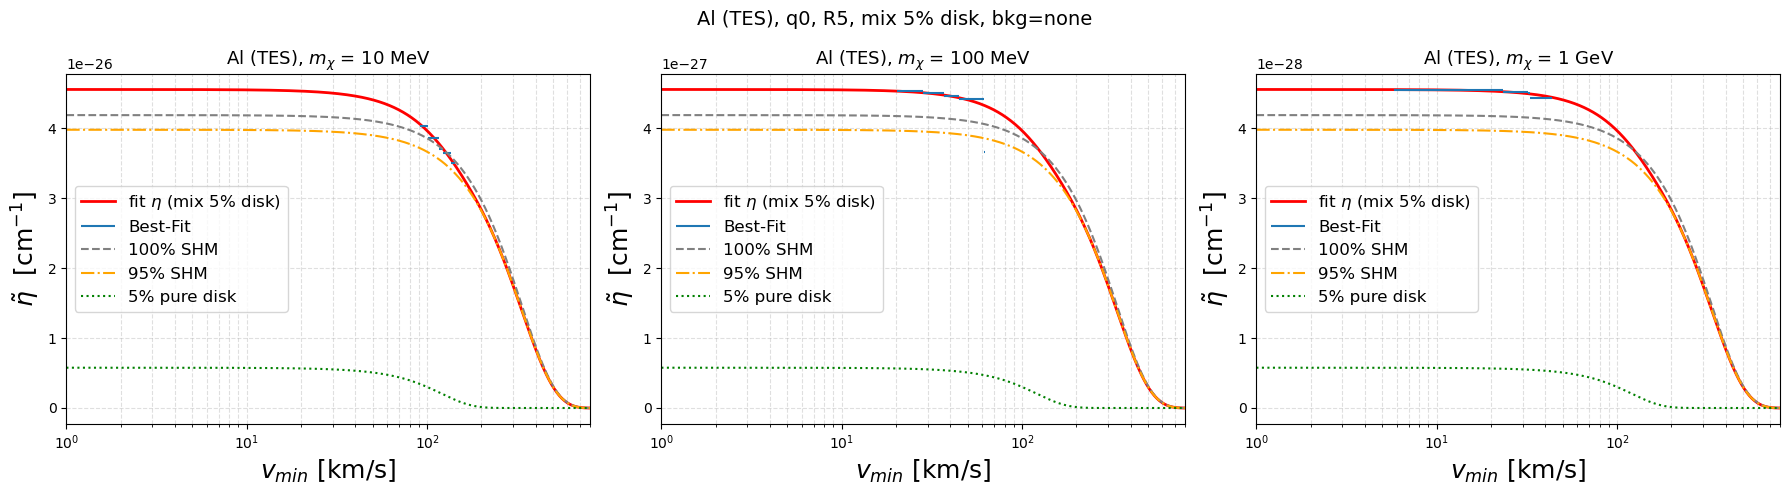

signal     : [ 804.98392563 1501.65246501 2178.80596329 2787.58765548 3198.99287999]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M1_R5_mix25/flux.pdf
Al q0 M1 R5: 5 E-bins x 65 v_min bins, peak flux 9.05e+02
signal     : [106.93288788 215.59492786 313.67785008 388.32111195 452.00005125]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R5_mix25/flux.pdf
Al q0 M2 R5: 5 E-bins x 53 v_min bins, peak flux 1.18e+02
signal     : [11.04290828 20.65915864 30.36115073 39.74516646 49.35698438]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M3_R5_mix25/flux.pdf
Al q0 M3 R5: 5 E-bins x 47 v_min bins, peak flux 1.19e+01


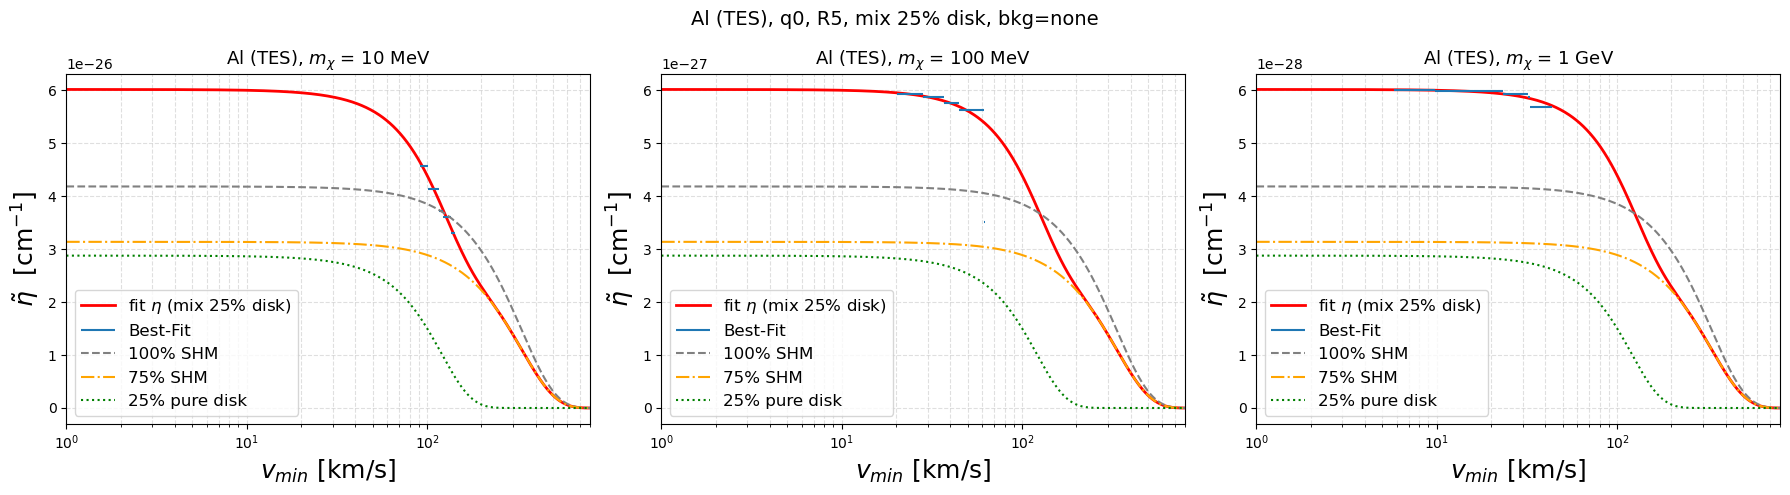

In [6]:
for p in DISK_FRACTIONS:
    run_masses('Al', q='0', nbins=5, disk_fraction=p, solver = 'scipy')

### Light mediator (q2), 5 energy bins

signal     : [ 742.54271917 1388.82750758 1889.14129578 2336.91539786 2764.06478736]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M1_R5_mix5/flux.pdf
Al q2 M1 R5: 5 E-bins x 106 v_min bins, peak flux 8.42e+02
signal     : [ 70.72320932 136.67781897 194.66334269 247.00388555 294.16686855]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M2_R5_mix5/flux.pdf
Al q2 M2 R5: 5 E-bins x 115 v_min bins, peak flux 8.95e+01
signal     : [ 6.9772298  13.68453733 19.33550266 24.53443007 29.25793156]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M3_R5_mix5/flux.pdf
Al q2 M3 R5: 5 E-bins x 119 v_min bins, peak flux 8.97e+00


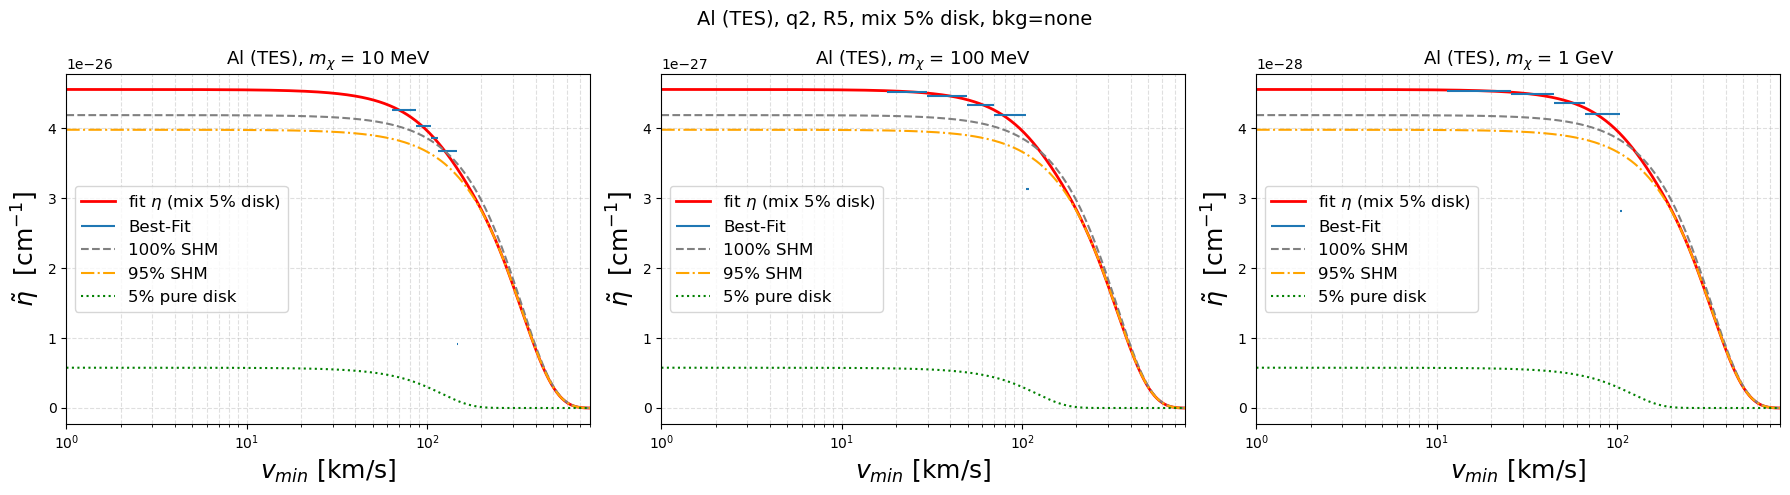

signal     : [ 905.86693847 1587.36185436 2015.77658387 2340.24837088 2613.12775573]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M1_R5_mix25/flux.pdf
Al q2 M1 R5: 5 E-bins x 106 v_min bins, peak flux 1.03e+03
signal     : [ 92.78651405 176.89443663 246.46219852 303.03087484 346.44190112]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M2_R5_mix25/flux.pdf
Al q2 M2 R5: 5 E-bins x 115 v_min bins, peak flux 1.17e+02
signal     : [ 9.18106523 17.8012985  24.67042355 30.4230413  34.93106372]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M3_R5_mix25/flux.pdf
Al q2 M3 R5: 5 E-bins x 119 v_min bins, peak flux 1.18e+01


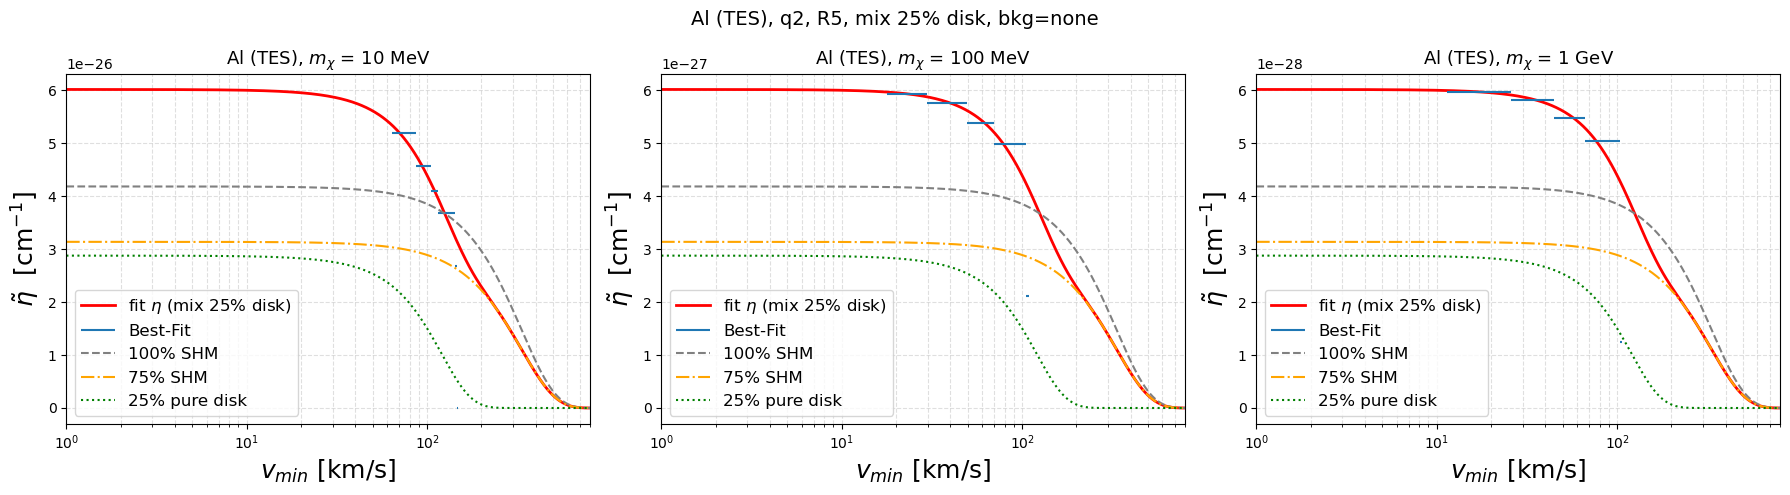

In [7]:
for p in DISK_FRACTIONS:
    run_masses('Al', q='2', nbins=5, disk_fraction=p)

### Heavy mediator (q0), 10 energy bins

signal     : [ 279.77789482  474.9077399   663.72711295  817.91611903 1008.78339772
 1213.02014768 1383.14237012 1502.92453465 1693.74806361 1834.5430321 ]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M1_R10_mix5/flux.pdf
Al q0 M1 R10: 10 E-bins x 69 v_min bins, peak flux 8.03e+02
signal     : [ 35.92454232  62.13826909  76.49569478 103.66701724 109.77112307
 133.73814438 147.87221797 161.52616287 192.64962486 201.8906599 ]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R10_mix5/flux.pdf
Al q0 M2 R10: 10 E-bins x 60 v_min bins, peak flux 8.97e+01
signal     : [ 3.04250582  5.29209266  6.81456065  9.19985247 10.764416   13.03801159
 14.5280253  16.851975   18.52700628 20.2344794 ]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/Quant

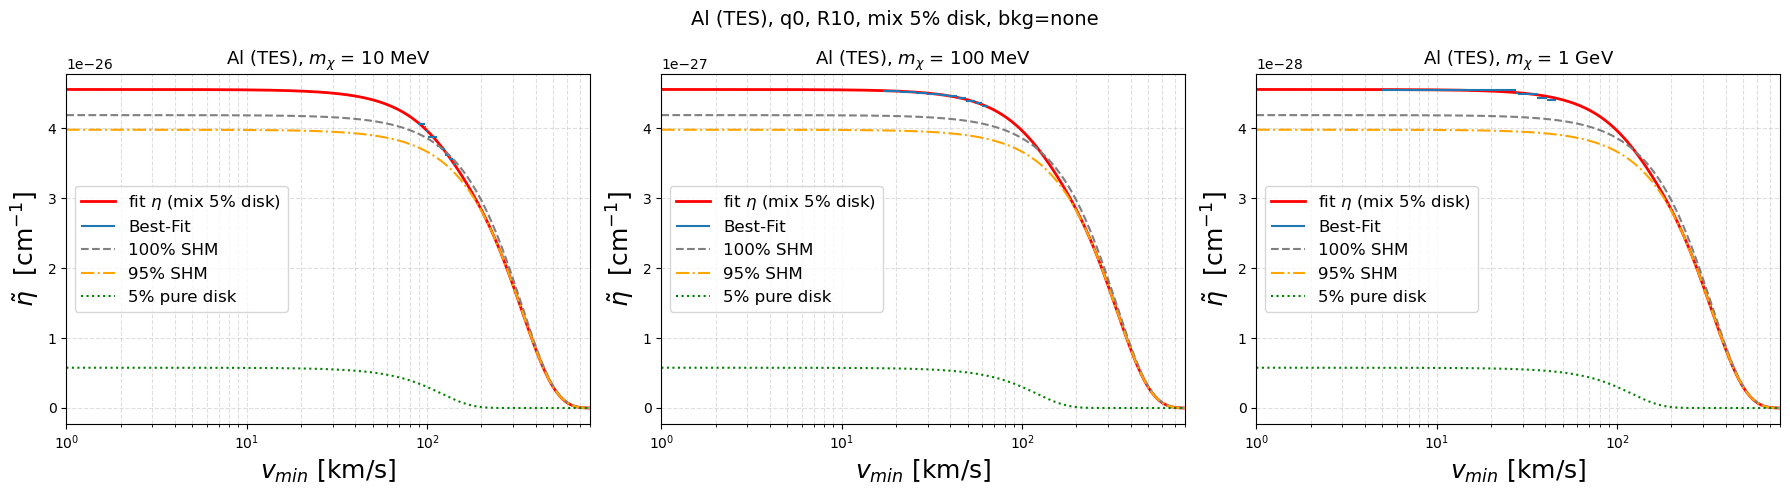

signal     : [ 313.18094746  521.35258605  716.01380756  865.42323158 1086.42892741
 1268.12507125 1402.88396469 1483.44642565 1630.08904075 1718.46687728]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M1_R10_mix25/flux.pdf
Al q0 M1 R10: 10 E-bins x 69 v_min bins, peak flux 9.19e+02
signal     : [ 47.28586365  81.59174255 100.11424121 135.17156562 142.44201377
 172.64467596 189.56917396 205.40328723 242.88446593 252.2942485 ]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M2_R10_mix25/flux.pdf
Al q0 M2 R10: 10 E-bins x 60 v_min bins, peak flux 1.18e+02
signal     : [ 4.02027007  6.99025911  8.99727903 12.13767359 14.19294034 17.17177583
 19.11718682 22.14283683 24.31667474 26.52392163]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/Qua

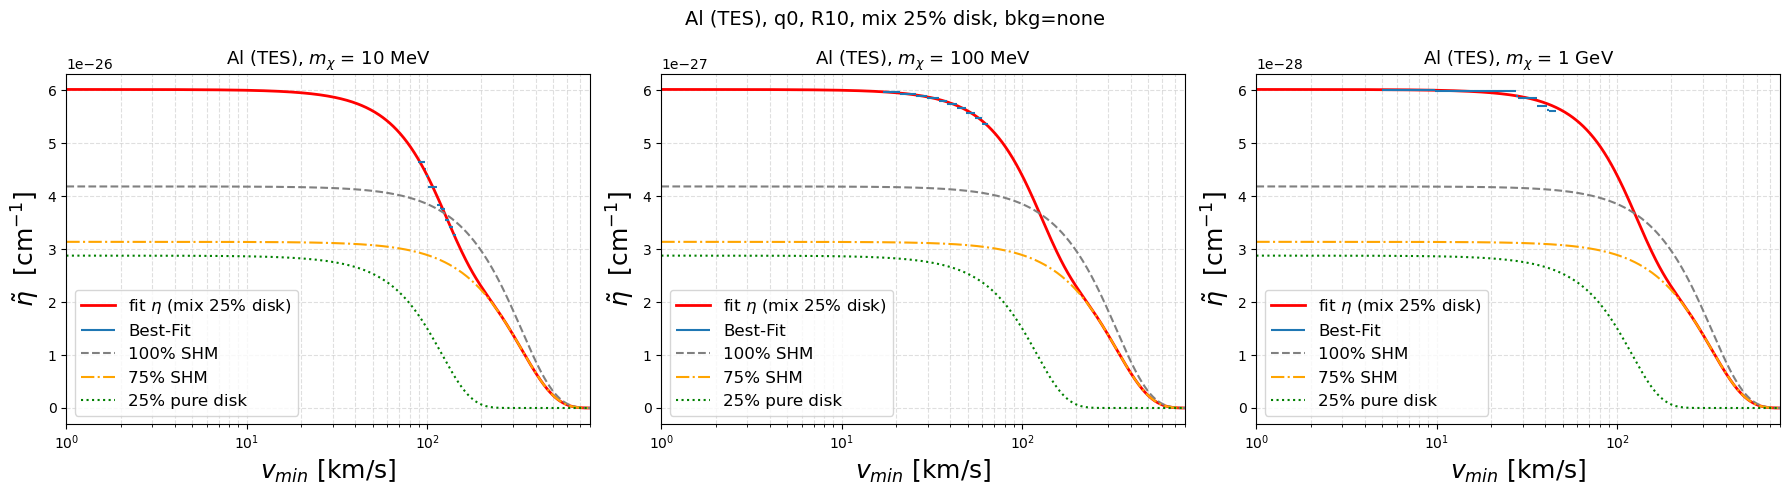

In [8]:
for p in DISK_FRACTIONS:
    run_masses('Al', q='0', nbins=10, disk_fraction=p, solver = 'scipy')

### Light mediator (q2), 10 energy bins

signal     : [ 293.02926631  483.00717432  630.86352832  803.67683243  950.15724848
 1076.24969026 1189.72193733 1273.40405018 1384.38434133 1477.13555473]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M1_R10_mix5/flux.pdf
Al q2 M1 R10: 10 E-bins x 122 v_min bins, peak flux 8.61e+02
signal     : [ 28.41828848  46.71176239  64.02978301  80.43271358  93.91632362
 109.07671001 123.42326644 135.37133766 148.66131176 159.26221398]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M2_R10_mix5/flux.pdf
Al q2 M2 R10: 10 E-bins x 122 v_min bins, peak flux 8.97e+01
signal     : [ 2.81340346  4.64129907  6.27747389  7.88083718  9.42552169 10.93451512
 12.37051579 13.56193906 14.73205816 15.99453072]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/Qua

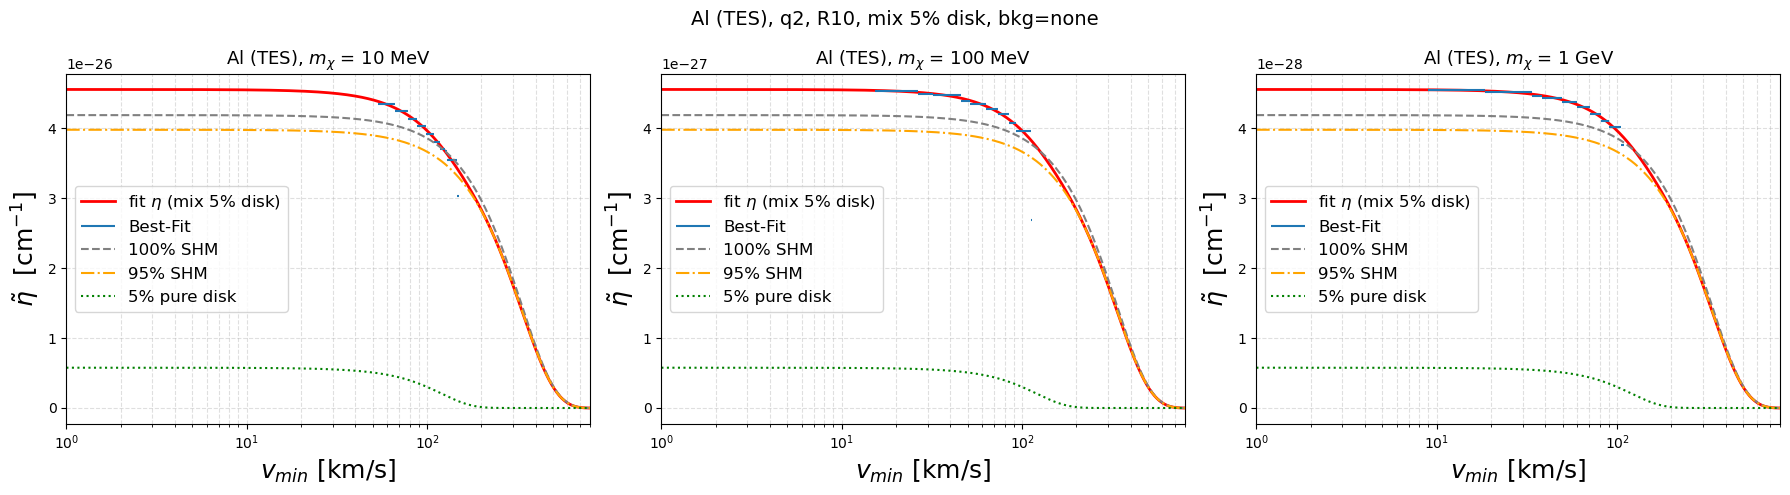

signal     : [ 367.6104669   588.05165752  741.98011753  913.51860619 1040.92690014
 1137.04053796 1217.07909562 1259.13485651 1329.15905776 1380.56434816]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M1_R10_mix25/flux.pdf
Al q2 M1 R10: 10 E-bins x 122 v_min bins, peak flux 1.08e+03
signal     : [ 37.39365535  61.19525068  83.29171699 103.71529735 119.83751149
 137.32412565 152.91944091 165.08355494 177.59039155 186.17401763]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M2_R10_mix25/flux.pdf
Al q2 M2 R10: 10 E-bins x 122 v_min bins, peak flux 1.18e+02
signal     : [ 3.70956479  6.09689397  8.20508134 10.22509713 12.11292511 13.88565186
 15.48466581 16.70692965 17.85407587 18.97809925]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/Q

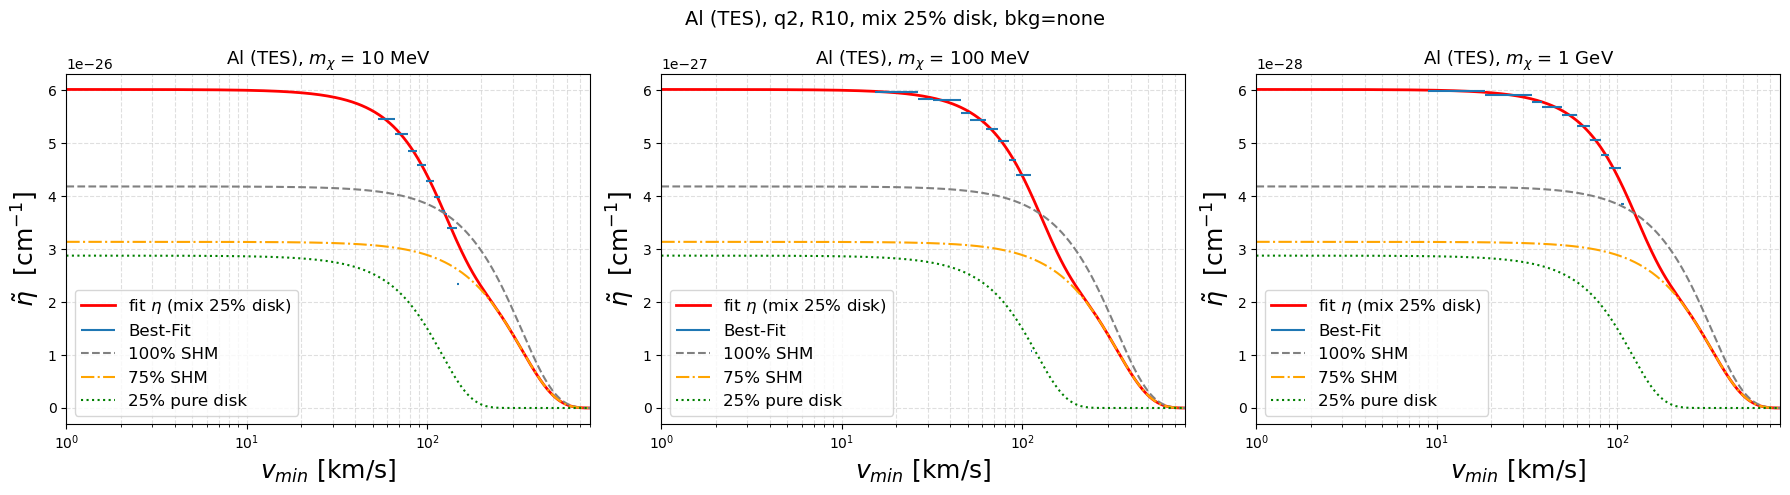

In [9]:
for p in DISK_FRACTIONS:
    run_masses('Al', q='2', nbins=10, disk_fraction=p)

## Bound (Earth-bound thermal DM)

Dense (`rho_b = 1e14` GeV/cm^3), isotropic, cold (`v0 ~ 2.16` km/s at 1 GeV), `vesc = 11.2` km/s. Only **M3 (1 GeV)** is shown: the bound population is too slow to reach the `v_min` thresholds of the lighter masses (M1/M2 have no signal).

### Heavy mediator (q0), 5 energy bins

signal     : [2.07274253e+13 1.66792087e+11 1.43354672e+08 2.78455541e+01
 3.47081875e+01]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M3_R5_Bound/flux.pdf
Al q0 M3 R5: 5 E-bins x 47 v_min bins, peak flux 4.12e+13


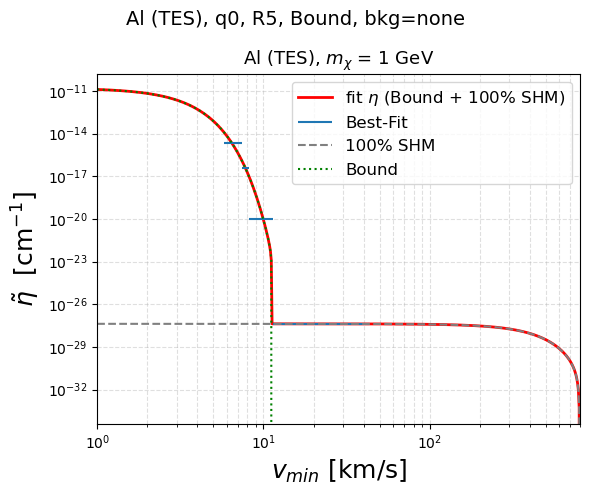

In [10]:
run_masses('Al', q='0', nbins=5, eta='Bound', masses=('3',))

### Light mediator (q2), 5 energy bins

signal     : [ 6.42627095 12.65534704 18.00177244 23.06227726 27.83964852]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M3_R5_Bound/flux.pdf
Al q2 M3 R5: 5 E-bins x 119 v_min bins, peak flux 8.26e+00


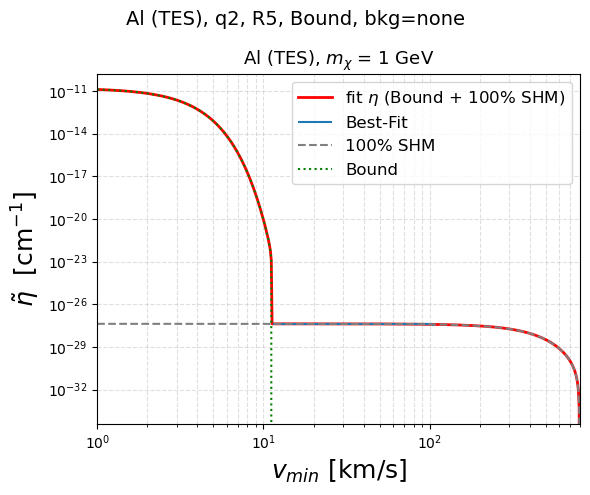

In [11]:
run_masses('Al', q='2', nbins=5, eta='Bound', masses=('3',))

### Heavy mediator (q0), 10 energy bins

signal     : [8.15170680e+13 9.73575431e+12 1.62192218e+11 6.25499599e+09
 1.41881729e+08 2.50621826e+06 1.33807349e+01 1.55292595e+01
 1.70795892e+01 1.86621188e+01]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q0_M3_R10_Bound/flux.pdf
Al q0 M3 R10: 10 E-bins x 51 v_min bins, peak flux 6.02e+14


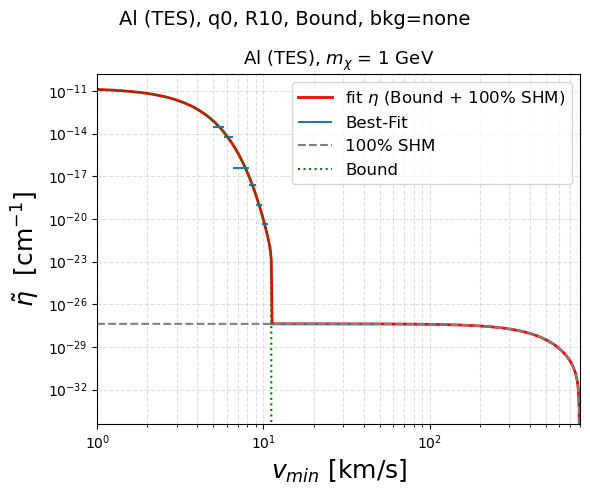

In [12]:
run_masses('Al', q='0', nbins=10, eta='Bound', masses=('3',))

### Light mediator (q2), 10 energy bins

signal     : [5.14224741e+07 4.27740035e+00 5.79557203e+00 7.29477219e+00
 8.75367084e+00 1.01967309e+01 1.15919783e+01 1.27756914e+01
 1.39515537e+01 1.52486386e+01]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/TES/bkg-none/Al_q2_M3_R10_Bound/flux.pdf
Al q2 M3 R10: 10 E-bins x 126 v_min bins, peak flux 3.27e+08


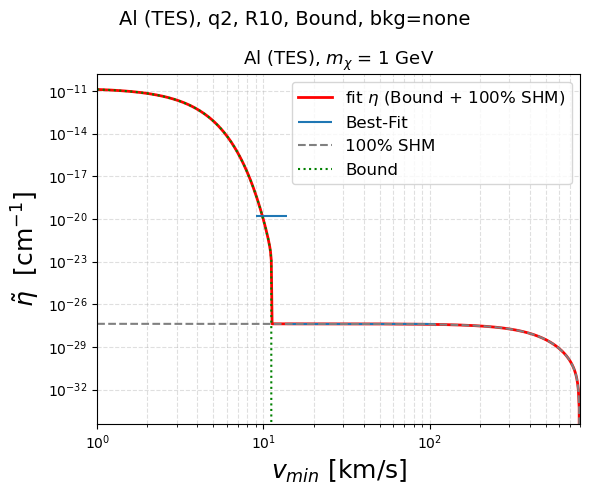

In [13]:
run_masses('Al', q='2', nbins=10, eta='Bound', masses=('3',))

## With a background scenario (Halo)

signal     : [ 705.55175893 1378.01639166 2073.97204148 2822.89736877 3443.58224531]
background : [40.21562004 39.56384709 38.92498011 38.29876355 37.68494691]
Al q0 M1 R5: 5 E-bins x 65 v_min bins, peak flux 7.71e+02
signal     : [ 75.04064212 152.5696063  224.8560444  282.99026892 337.02974027]
background : [40.21562004 39.56384709 38.92498011 38.29876355 37.68494691]
Al q0 M2 R5: 5 E-bins x 53 v_min bins, peak flux 8.25e+01
signal     : [ 7.68835856 14.40117892 21.20924145 27.84555407 34.70818753]
background : [40.21562004 39.56384709 38.92498011 38.29876355 37.68494691]
Al q0 M3 R5: 5 E-bins x 47 v_min bins, peak flux 8.28e+00


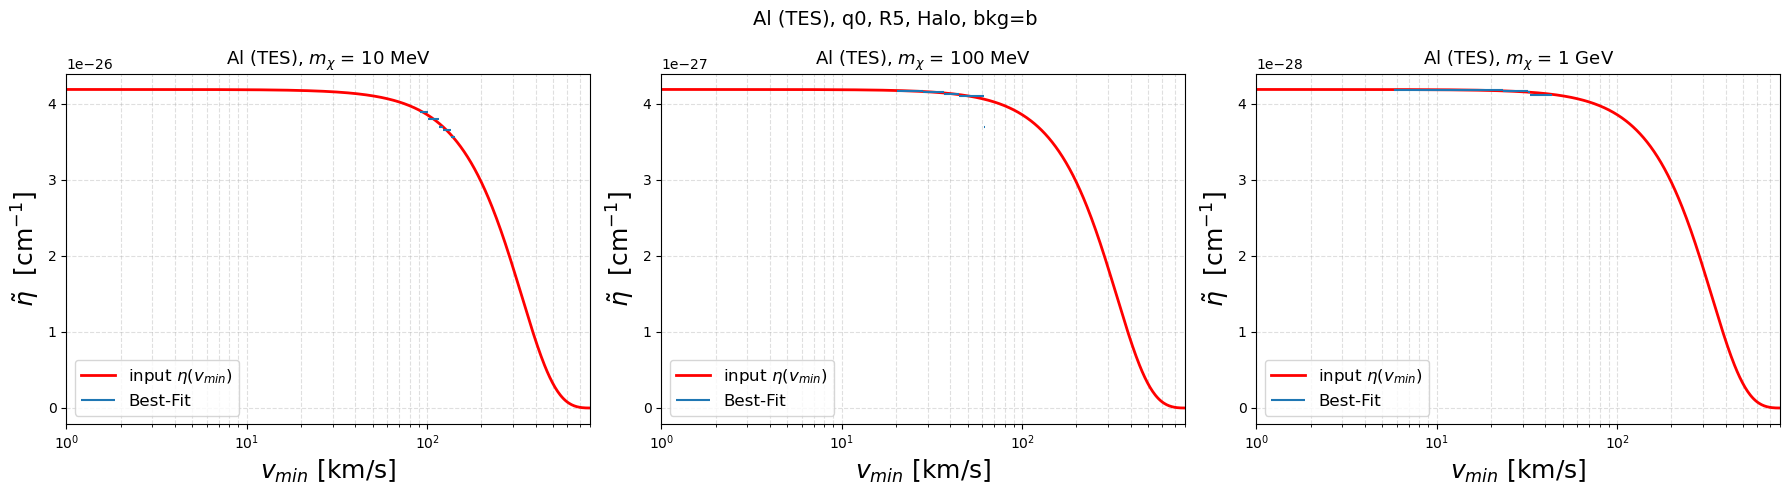

In [14]:
run_masses('Al', q='0', nbins=5, eta='Halo', background='b', solver = 'scipy', save = False)

signal     : [ 701.71166434 1339.19392089 1857.48247376 2336.0821546  2801.79904526]
background : [40.21562004 39.56384709 38.92498011 38.29876355 37.68494691]
Al q2 M1 R5: 5 E-bins x 106 v_min bins, peak flux 7.95e+02
signal     : [ 65.20738314 126.62366456 181.71362873 232.99713822 281.0981104 ]
background : [40.21562004 39.56384709 38.92498011 38.29876355 37.68494691]
Al q2 M2 R5: 5 E-bins x 115 v_min bins, peak flux 8.25e+01
signal     : [ 6.42627095 12.65534704 18.00177244 23.06227726 27.83964852]
background : [40.21562004 39.56384709 38.92498011 38.29876355 37.68494691]
Al q2 M3 R5: 5 E-bins x 119 v_min bins, peak flux 8.26e+00


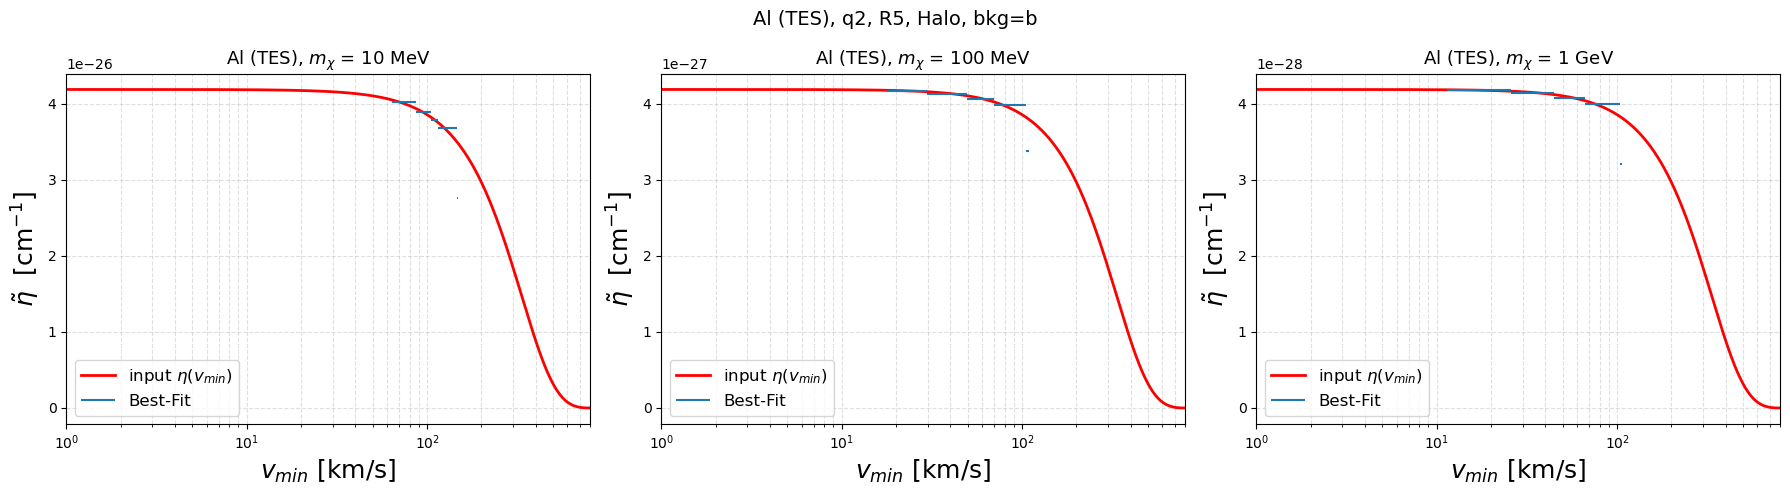

In [15]:
run_masses('Al', q='2', nbins=5, eta='Halo', background='b', save = False)

signal     : [ 705.55175893 1378.01639166 2073.97204148 2822.89736877 3443.58224531]
background : [5.03778479 4.9669399  4.89749784 4.82943082 4.76271162]
Al q0 M1 R5: 5 E-bins x 65 v_min bins, peak flux 7.71e+02
signal     : [ 75.04064212 152.5696063  224.8560444  282.99026892 337.02974027]
background : [5.03778479 4.9669399  4.89749784 4.82943082 4.76271162]
Al q0 M2 R5: 5 E-bins x 53 v_min bins, peak flux 8.25e+01
signal     : [ 7.68835856 14.40117892 21.20924145 27.84555407 34.70818753]
background : [5.03778479 4.9669399  4.89749784 4.82943082 4.76271162]
Al q0 M3 R5: 5 E-bins x 47 v_min bins, peak flux 8.28e+00


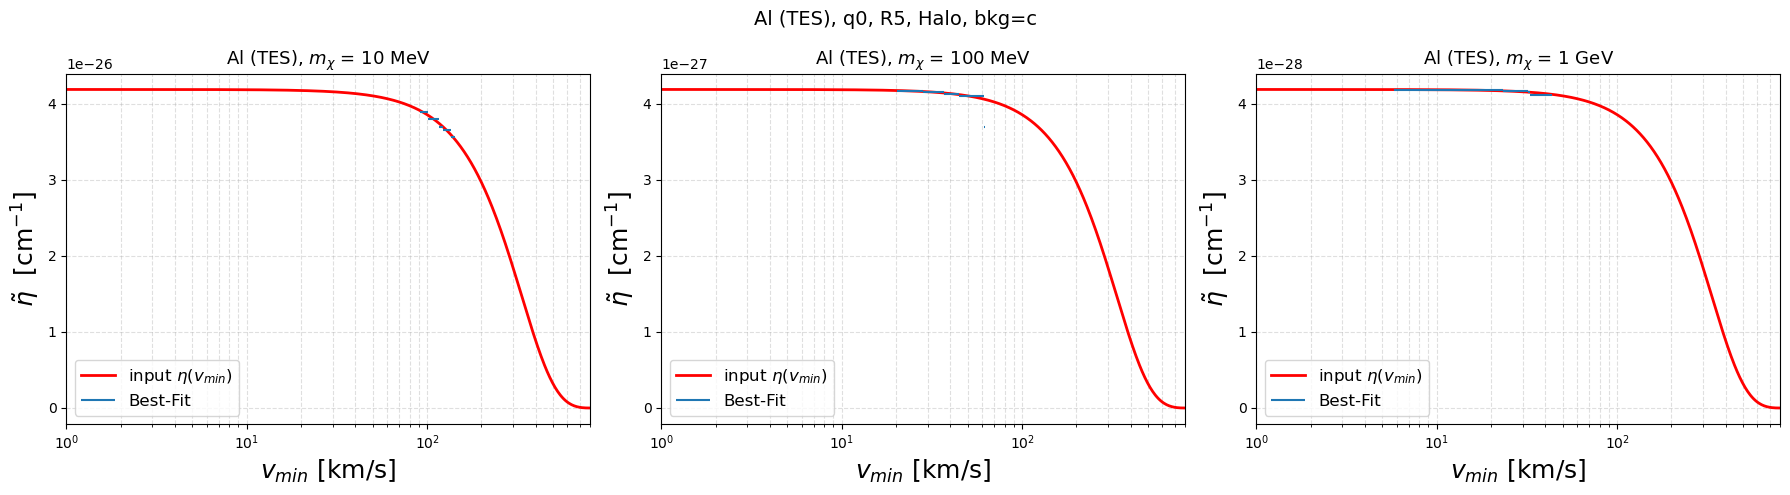

In [16]:
run_masses('Al', q='0', nbins=5, eta='Halo', background='c', solver = 'scipy', save = False)

signal     : [ 701.71166434 1339.19392089 1857.48247376 2336.0821546  2801.79904526]
background : [5.03778479 4.9669399  4.89749784 4.82943082 4.76271162]
Al q2 M1 R5: 5 E-bins x 106 v_min bins, peak flux 7.95e+02
signal     : [ 65.20738314 126.62366456 181.71362873 232.99713822 281.0981104 ]
background : [5.03778479 4.9669399  4.89749784 4.82943082 4.76271162]
Al q2 M2 R5: 5 E-bins x 115 v_min bins, peak flux 8.25e+01
signal     : [ 6.42627095 12.65534704 18.00177244 23.06227726 27.83964852]
background : [5.03778479 4.9669399  4.89749784 4.82943082 4.76271162]
Al q2 M3 R5: 5 E-bins x 119 v_min bins, peak flux 8.26e+00


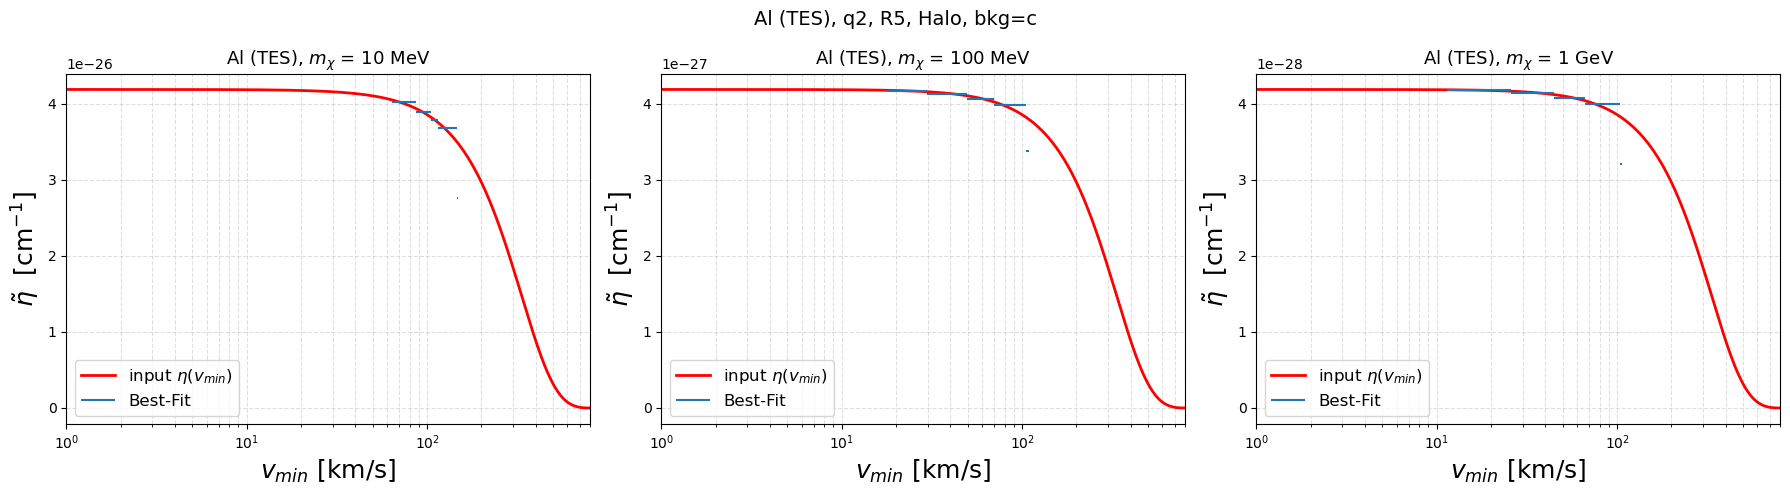

In [17]:
run_masses('Al', q='2', nbins=5, eta='Halo', background='c', save = False)

# MKID (TiN)

Titanium-nitride detector, Lindhard dielectric. Threshold **0.2 eV** (bins start at 0.2 eV, fine binning **`R9`**). Heavy mediator (`q0`) only so far.

## Halo (SHM) — reference

### Heavy mediator (q0), 5 energy bins

signal     : [ 445.21000877 1304.41782723 1978.16834829 2459.94457058 2905.68807014]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R5_Halo/flux.pdf
TiN q0 M1 R5: 5 E-bins x 90 v_min bins, peak flux 7.92e+02
signal     : [ 39.91093034 119.09481043 183.65374072 241.28025879 291.89546679]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R5_Halo/flux.pdf
TiN q0 M2 R5: 5 E-bins x 89 v_min bins, peak flux 8.24e+01
signal     : [ 4.27752758 12.44515178 18.80186551 23.09918991 29.5221322 ]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M3_R5_Halo/flux.pdf
TiN q0 M3 R5: 5 E-bins x 90 v_min bins, peak flux 8.25e+00


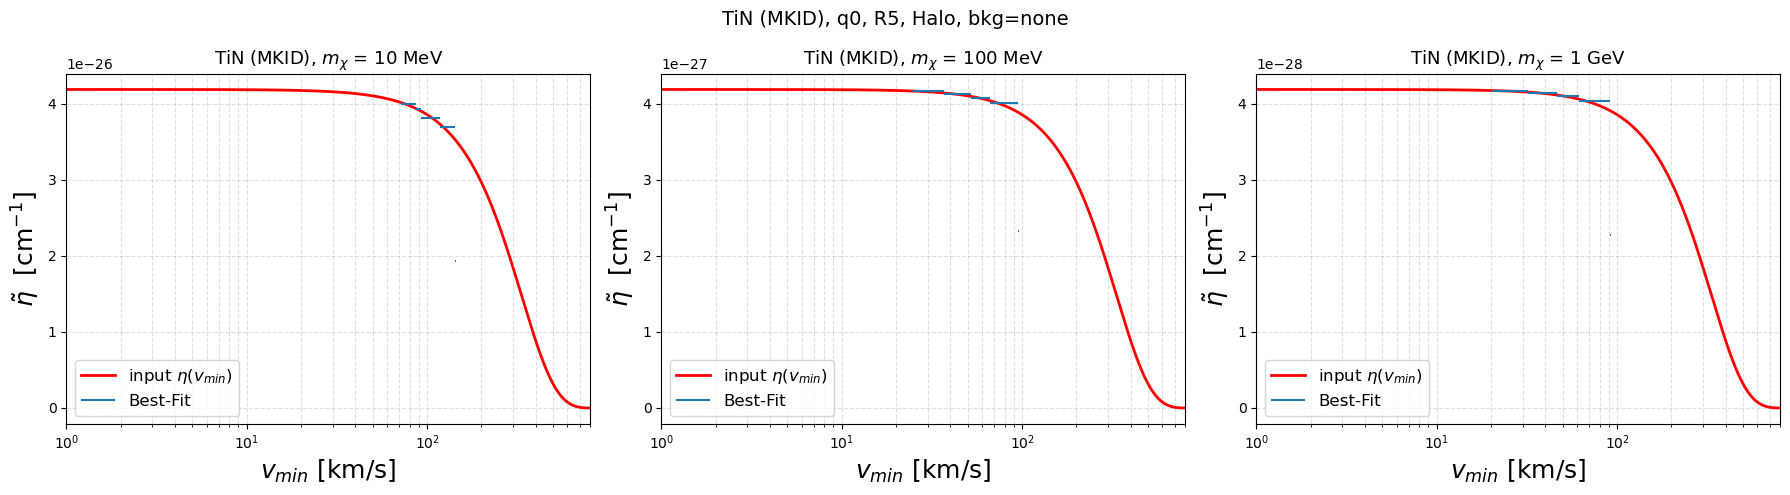

In [18]:
run_masses('TiN', q='0', nbins=5, eta='Halo', solver = 'scipy')

### Light mediator (q2), 5 energy bins

signal     : [ 3687.06444078 10263.85015221 13746.12876484 16406.21139068
 18427.27096844]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M1_R5_Halo/flux.pdf
TiN q2 M1 R5: 5 E-bins x 146 v_min bins, peak flux 7.95e+02
signal     : [ 348.7799947   968.44687624 1317.68670343 1607.96077904 1824.47808771]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M2_R5_Halo/flux.pdf
TiN q2 M2 R5: 5 E-bins x 167 v_min bins, peak flux 8.20e+01
signal     : [ 34.5706271   96.52392458 131.18113983 160.23791737 182.33304268]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M3_R5_Halo/flux.pdf
TiN q2 M3 R5: 5 E-bins x 169 v_min bins, peak flux 8.21e+00


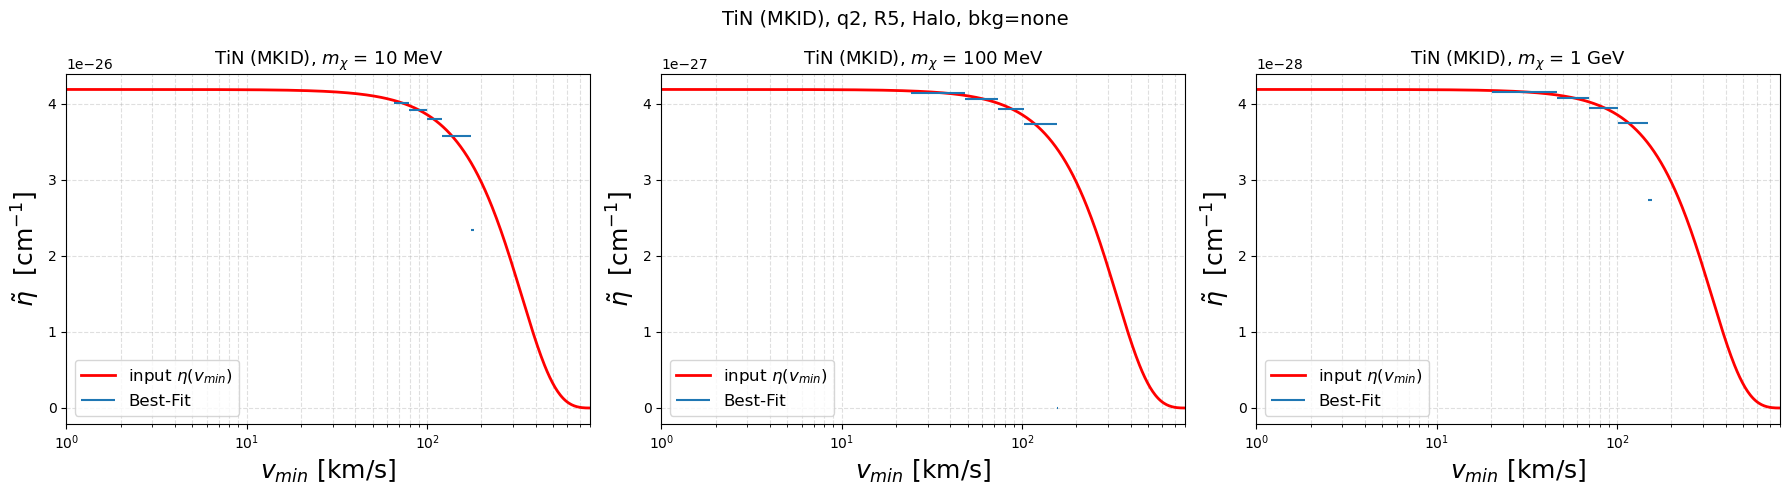

In [19]:
run_masses('TiN', q='2', nbins=5, eta='Halo')

### Heavy mediator (q0), 9 energy bins

signal     : [ 445.21000877  569.94142716  725.0087526   955.48703613 1118.6984344
 1252.69095406 1364.28309426 1455.63879625 1529.33814614]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R9_Halo/flux.pdf
TiN q0 M1 R9: 9 E-bins x 95 v_min bins, peak flux 7.97e+02
signal     : [ 39.91093034  61.37166604  73.57869481  92.78008433 102.89213857
 120.5052052  129.25312729 145.47224949 160.92992429]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R9_Halo/flux.pdf
TiN q0 M2 R9: 9 E-bins x 94 v_min bins, peak flux 8.24e+01
signal     : [ 4.27752758  5.617097    7.5639596   8.67668513 10.47073058 11.437067
 13.1108689  14.7214466  15.47577996]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN

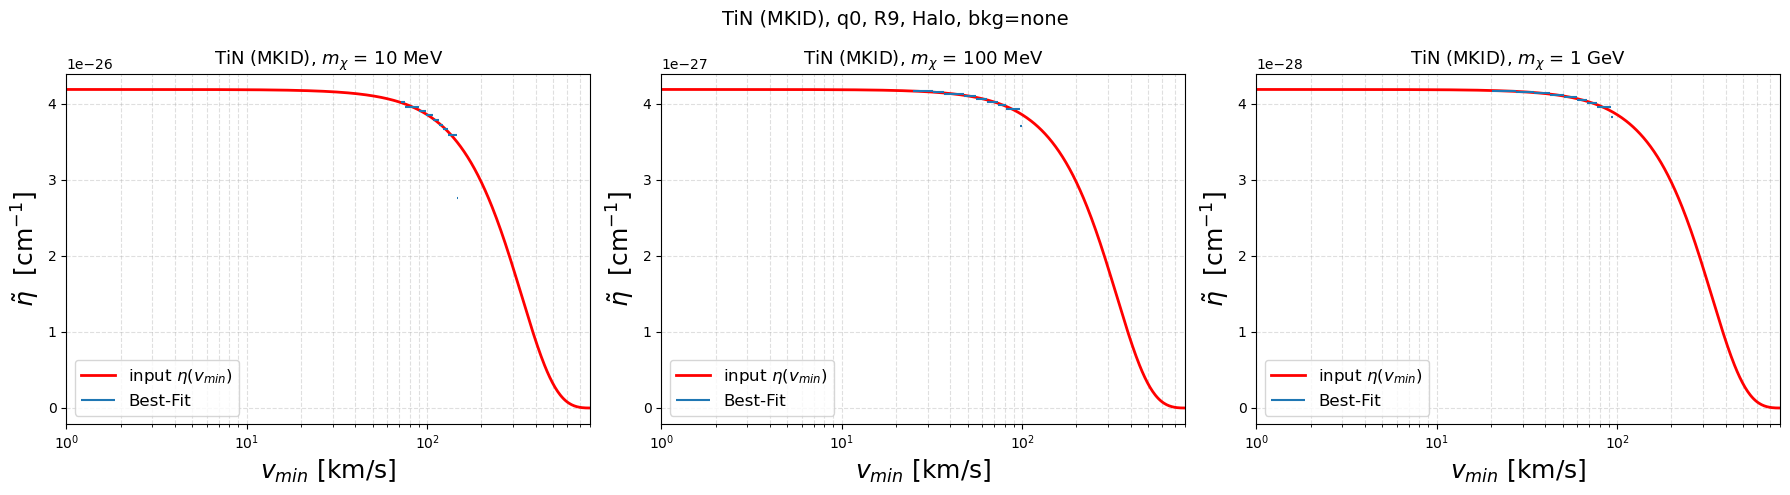

In [20]:
run_masses('TiN', q='0', nbins=9, eta='Halo')

### Light mediator (q2), 9 energy bins

signal     : [3687.06444078 4926.19057264 5871.89108417 6742.43932567 7615.88530744
 8310.38272408 8914.08693454 9453.21848286 9825.23089137]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M1_R9_Halo/flux.pdf
TiN q2 M1 R9: 9 E-bins x 152 v_min bins, peak flux 7.95e+02
signal     : [348.7799947  455.78449512 557.43018126 654.46330197 737.05314202
 806.82532856 872.19248851 932.54081783 978.36047906]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M2_R9_Halo/flux.pdf
TiN q2 M2 R9: 9 E-bins x 174 v_min bins, peak flux 8.30e+01
signal     : [34.5706271  46.00441225 55.300761   64.95009153 73.29779367 80.34635597
 86.95761825 92.95317059 97.76530251]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-non

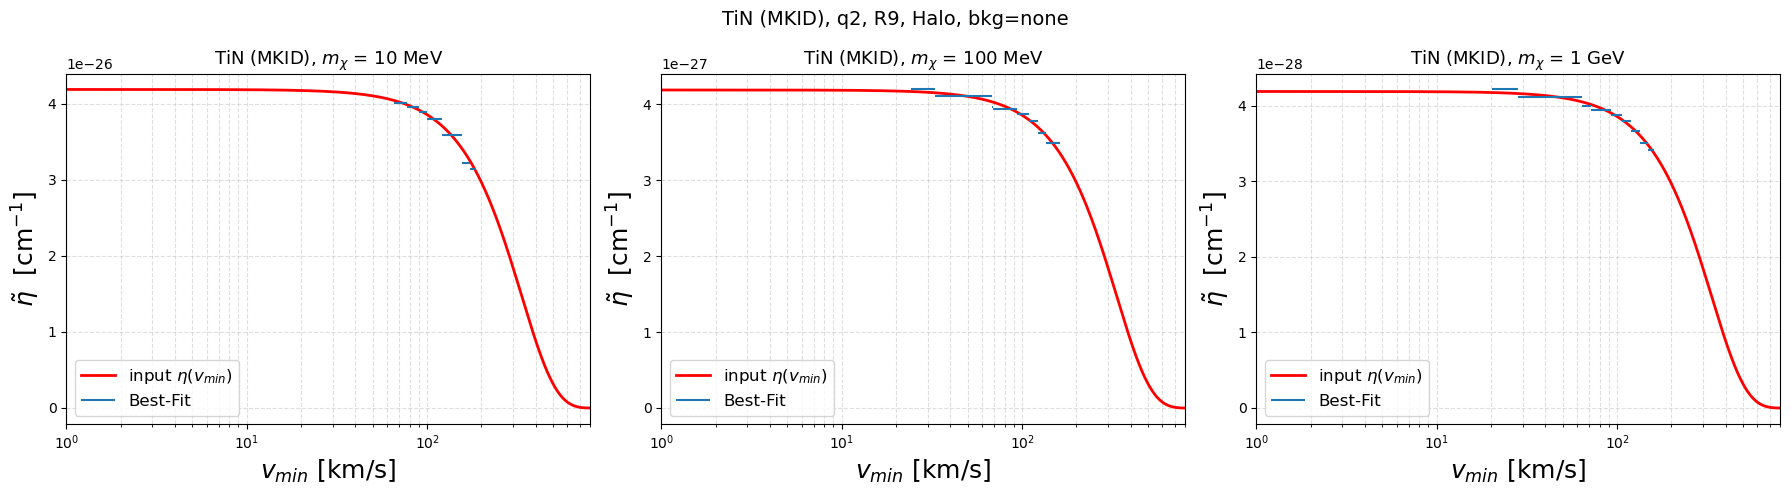

In [21]:
run_masses('TiN', q='2', nbins=9, eta='Halo')

## Mixture (best-fit) — sweep dark-disk fraction

`eta = (1-p)*Halo + p*Disk`. Each figure overlays 100% SHM (gray) and `p` x pure disk (green).

### Heavy mediator (q0), 5 energy bins

signal     : [ 469.60329666 1354.78407504 2020.13396358 2467.33502446 2865.84356001]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R5_mix5/flux.pdf
TiN q0 M1 R5: 5 E-bins x 90 v_min bins, peak flux 8.35e+02
signal     : [ 43.25348061 128.45785213 196.35041851 254.92844528 303.65384642]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R5_mix5/flux.pdf
TiN q0 M2 R5: 5 E-bins x 89 v_min bins, peak flux 8.93e+01
signal     : [ 4.64077035 13.44752355 20.16558999 24.50304229 30.84920443]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M3_R5_mix5/flux.pdf
TiN q0 M3 R5: 5 E-bins x 90 v_min bins, peak flux 8.95e+00


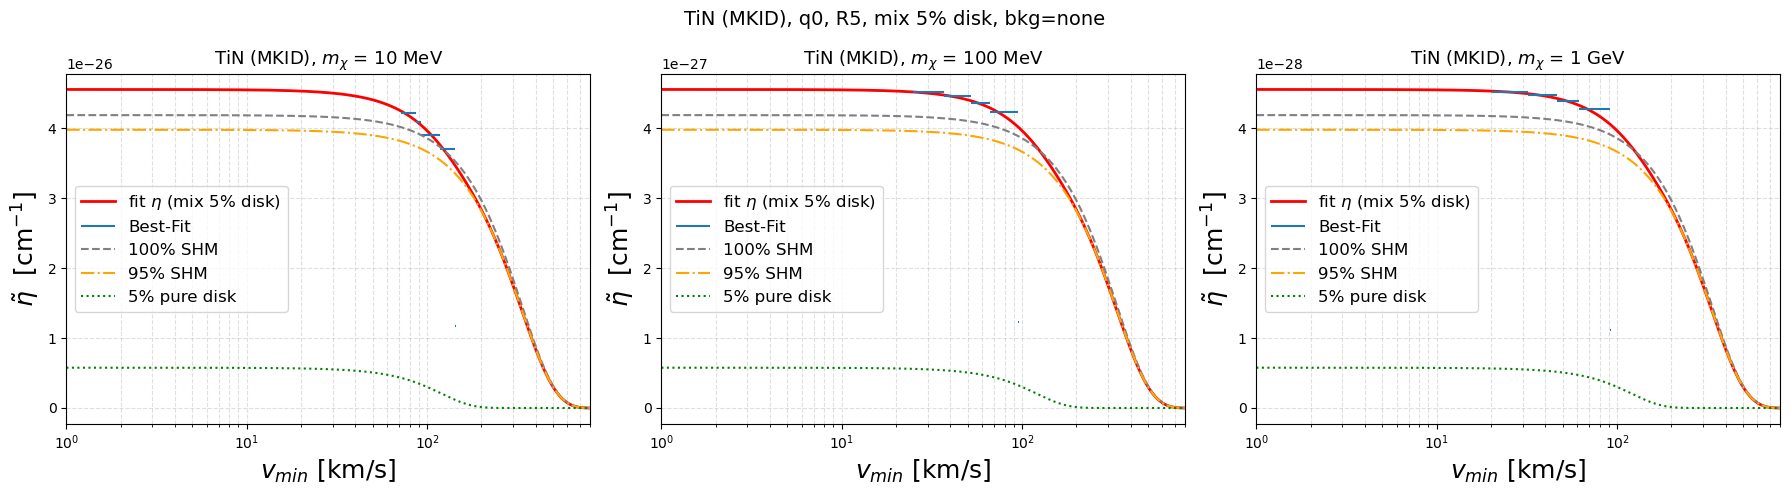

signal     : [ 567.17644822 1556.24906629 2187.99642475 2496.89683997 2706.46551948]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R5_mix25/flux.pdf
TiN q0 M1 R5: 5 E-bins x 90 v_min bins, peak flux 1.01e+03
signal     : [ 56.62368169 165.91001891 247.13712967 309.52119125 350.68736493]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R5_mix25/flux.pdf
TiN q0 M2 R5: 5 E-bins x 89 v_min bins, peak flux 1.17e+02
signal     : [ 6.09374143 17.45701065 25.62048788 30.1184518  36.15749336]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M3_R5_mix25/flux.pdf
TiN q0 M3 R5: 5 E-bins x 90 v_min bins, peak flux 1.18e+01


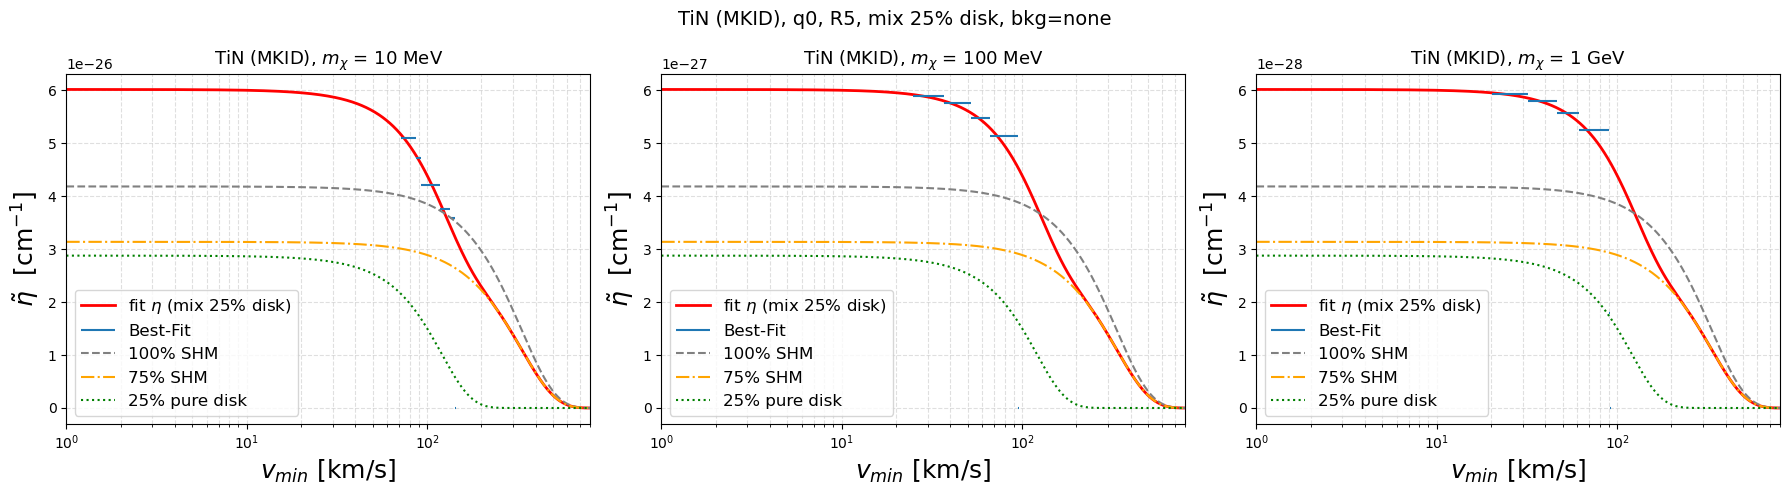

In [22]:
for p in DISK_FRACTIONS:
    run_masses('TiN', q='0', nbins=5, disk_fraction=p)

### Light mediator (q2), 5 energy bins

signal     : [ 3898.34506828 10667.60822422 13955.17269916 16280.17753573
 17964.34085015]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M1_R5_mix5/flux.pdf
TiN q2 M1 R5: 5 E-bins x 146 v_min bins, peak flux 8.40e+02
signal     : [ 376.87853311 1036.40126218 1386.19679603 1655.9711938  1837.82086972]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M2_R5_mix5/flux.pdf
TiN q2 M2 R5: 5 E-bins x 167 v_min bins, peak flux 8.86e+01
signal     : [ 37.39088848 103.46176791 138.32428524 165.4910222  184.32998257]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M3_R5_mix5/flux.pdf
TiN q2 M3 R5: 5 E-bins x 169 v_min bins, peak flux 8.88e+00


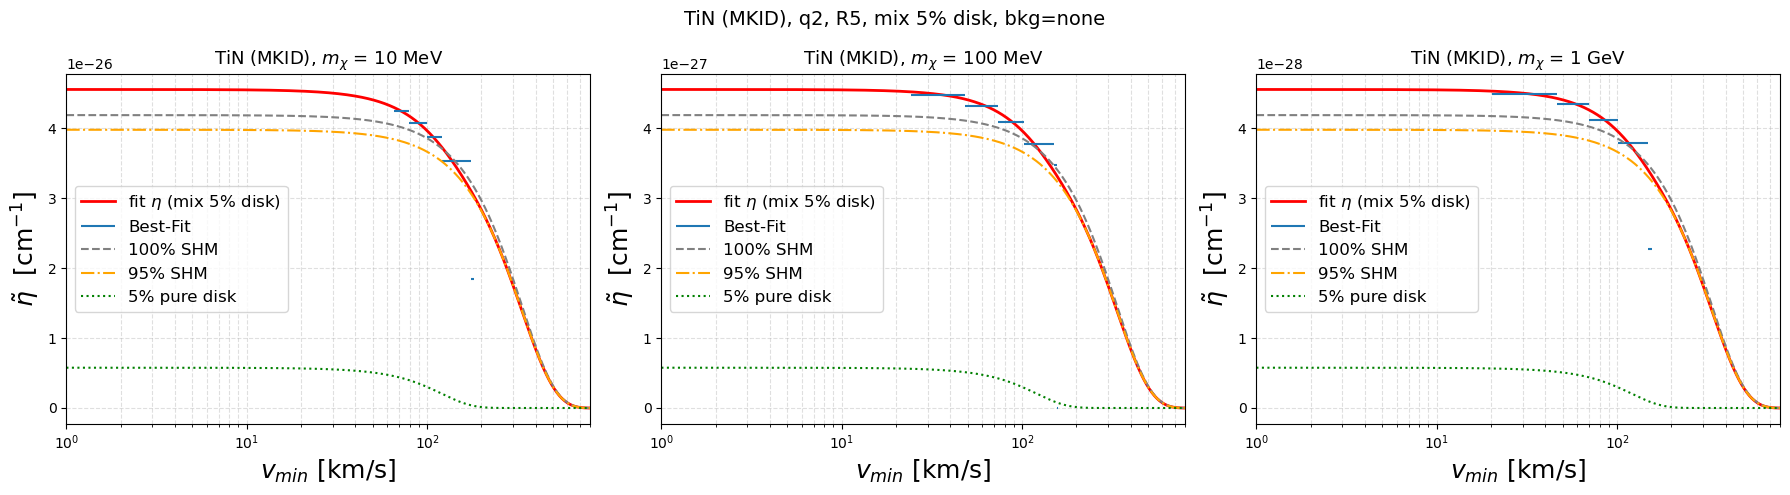

signal     : [ 4743.46757825 12282.64051226 14791.34843647 15776.04211594
 16112.62037701]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M1_R5_mix25/flux.pdf
TiN q2 M1 R5: 5 E-bins x 146 v_min bins, peak flux 1.02e+03
signal     : [ 489.27268675 1308.21880593 1660.23716644 1848.01285283 1891.19199773]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M2_R5_mix25/flux.pdf
TiN q2 M2 R5: 5 E-bins x 167 v_min bins, peak flux 1.15e+02
signal     : [ 48.67193402 131.21314124 166.89686691 186.50344151 192.31774214]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M3_R5_mix25/flux.pdf
TiN q2 M3 R5: 5 E-bins x 169 v_min bins, peak flux 1.16e+01


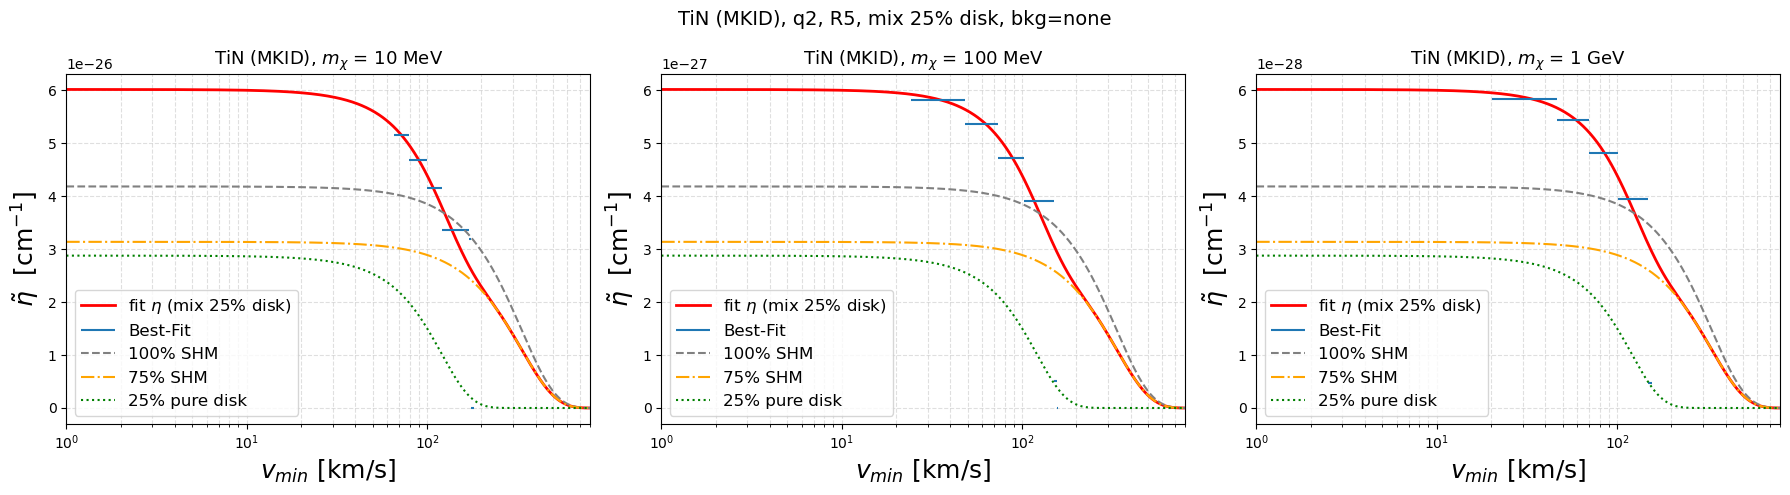

In [23]:
for p in DISK_FRACTIONS:
    run_masses('TiN', q='2', nbins=5, disk_fraction=p)

### Heavy mediator (q0), 9 energy bins

signal     : [ 469.60329666  596.03700238  751.4357013   981.35412257 1137.37375625
 1260.79293023 1361.97183095 1441.00814826 1502.3841074 ]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R9_mix5/flux.pdf
TiN q0 M1 R9: 9 E-bins x 95 v_min bins, peak flux 8.44e+02
signal     : [ 43.25348061  66.34418799  79.26495608  99.53296101 109.7980866
 127.75436774 136.13502079 151.95312623 166.72235575]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R9_mix5/flux.pdf
TiN q0 M2 R9: 9 E-bins x 94 v_min bins, peak flux 8.93e+01
signal     : [ 4.64077035  6.08193519  8.16676995  9.33253565 11.20626539 12.17682989
 13.86271403 15.45432748 16.11323618]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/T

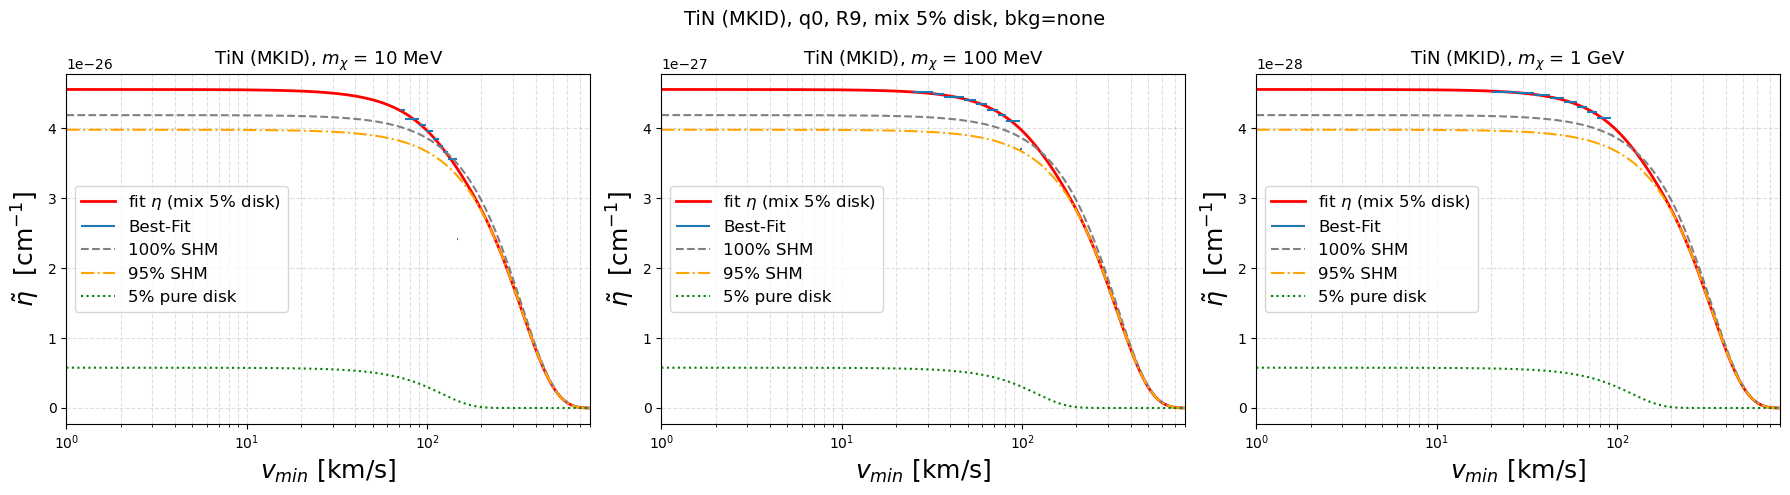

signal     : [ 567.17644822  700.41930325  857.14349612 1084.82246832 1212.07504364
 1293.20083491 1352.72677772 1382.48555629 1394.56795241]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M1_R9_mix25/flux.pdf
TiN q0 M1 R9: 9 E-bins x 95 v_min bins, peak flux 1.03e+03
signal     : [ 56.62368169  86.23427581 102.01000119 126.54446774 137.42187869
 156.7510179  163.66259476 177.87663318 189.89208158]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M2_R9_mix25/flux.pdf
TiN q0 M2 R9: 9 E-bins x 94 v_min bins, peak flux 1.17e+02
signal     : [ 6.09374143  7.94128793 10.57801136 11.95593772 14.14840463 15.13588147
 16.87009454 18.385851   18.66306109]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-non

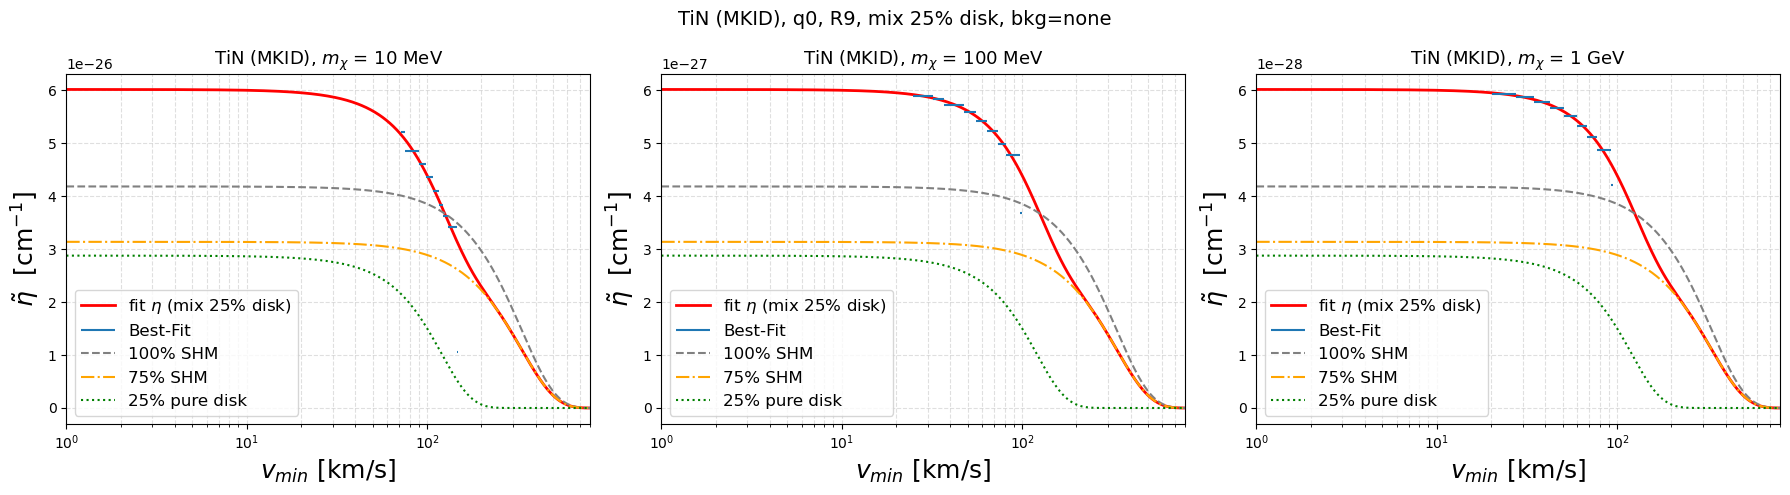

In [24]:
for p in DISK_FRACTIONS:
    run_masses('TiN', q='0', nbins=9, disk_fraction=p)

### Light mediator (q2), 9 energy bins

signal     : [3898.34506828 5154.23514545 6074.1150365  6893.67054383 7690.00634518
 8293.84992836 8806.18231137 9256.06413878 9550.20651215]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M1_R9_mix5/flux.pdf
TiN q2 M1 R9: 9 E-bins x 152 v_min bins, peak flux 8.40e+02
signal     : [376.87853311 489.77434533 594.76535945 692.54450472 771.85723588
 836.08533213 893.94061051 945.34078975 981.02151849]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M2_R9_mix5/flux.pdf
TiN q2 M2 R9: 9 E-bins x 174 v_min bins, peak flux 9.04e+01
signal     : [37.39088848 49.50725925 59.13112407 68.87426791 76.99298281 83.54063459
 89.44382505 94.50653995 98.38017617]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-non

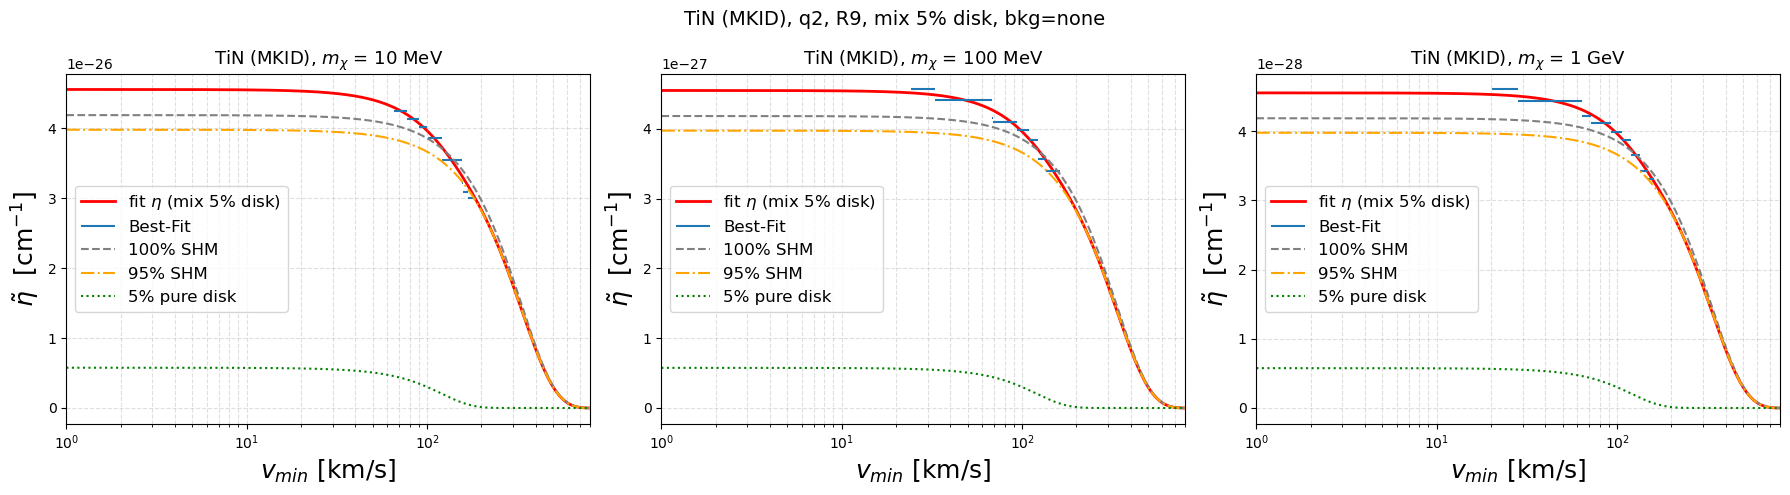

signal     : [4743.46757825 6066.41343666 6883.0108458  7498.5954165  7986.49049613
 8227.7187455  8374.5638187  8467.44676245 8450.10899527]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M1_R9_mix25/flux.pdf
TiN q2 M1 R9: 9 E-bins x 152 v_min bins, peak flux 1.02e+03
signal     : [489.27268675 625.73374615 744.10607224 844.86931573 911.07361131
 953.12534642 980.93309853 996.54067743 991.66567621]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M2_R9_mix25/flux.pdf
TiN q2 M2 R9: 9 E-bins x 174 v_min bins, peak flux 1.20e+02
signal     : [ 48.67193402  63.51864727  74.45257635  84.57097341  91.77373938
  96.31774908  99.38865224 100.72001741 100.83967084]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/M

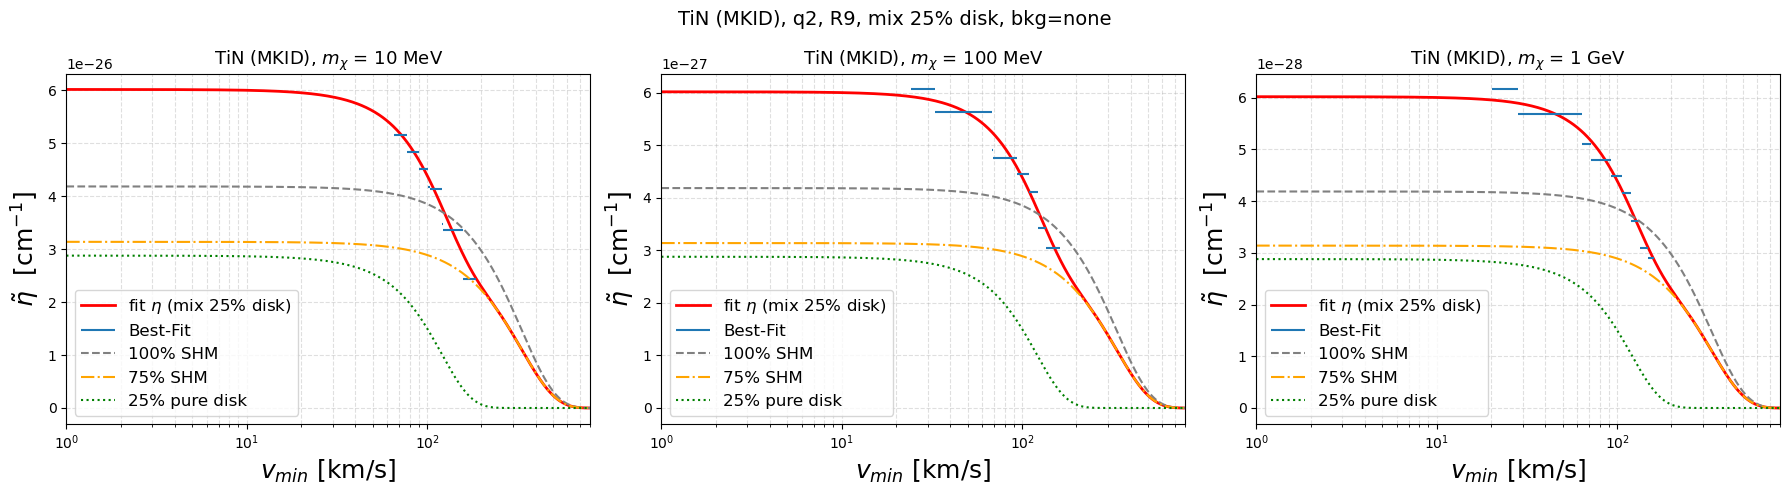

In [25]:
for p in DISK_FRACTIONS:
    run_masses('TiN', q='2', nbins=9, disk_fraction=p)

## Bound (Earth-bound thermal DM)

Dense (`rho_b = 1e14` GeV/cm^3), isotropic, cold (`v0 ~ 2.16` km/s at 1 GeV), `vesc = 11.2` km/s. Only **M3 (1 GeV)** is shown: the bound population is too slow to reach the `v_min` thresholds of the lighter masses (M1/M2 have no signal).

### Heavy mediator (q0), 5 energy bins

signal     : [ 4.27752758 12.44515178 18.80186551 23.09918991 29.5221322 ]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M3_R5_Bound/flux.pdf
TiN q0 M3 R5: 5 E-bins x 90 v_min bins, peak flux 8.25e+00


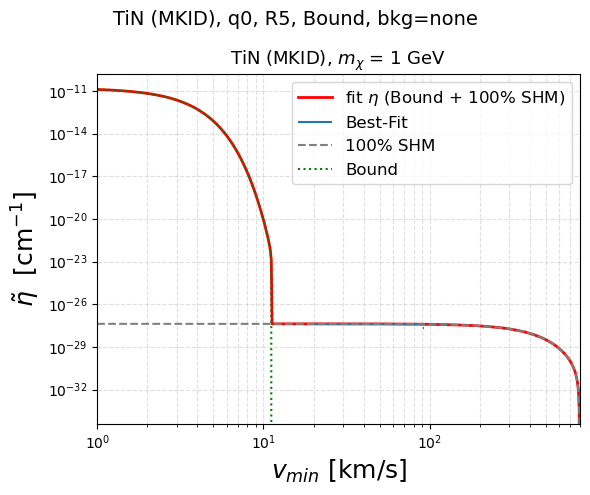

In [26]:
run_masses('TiN', q='0', nbins=5, eta='Bound', masses=('3',))

### Light mediator (q2), 5 energy bins

signal     : [ 34.5706271   96.52392458 131.18113983 160.23791737 182.33304268]
background : [0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M3_R5_Bound/flux.pdf
TiN q2 M3 R5: 5 E-bins x 169 v_min bins, peak flux 8.21e+00


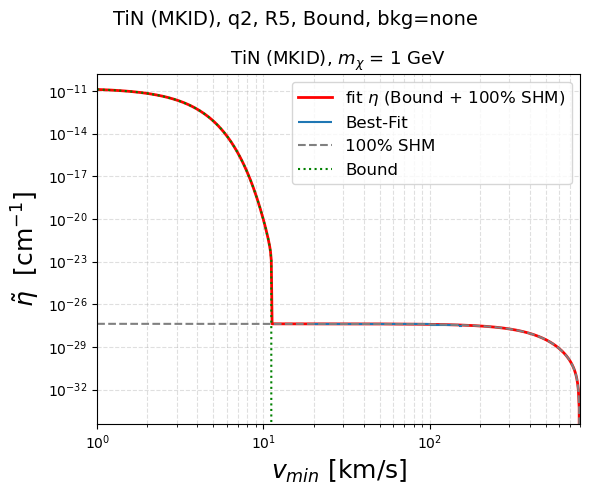

In [27]:
run_masses('TiN', q='2', nbins=5, eta='Bound', masses=('3',))

### Heavy mediator (q0), 9 energy bins

signal     : [ 4.27752758  5.617097    7.5639596   8.67668513 10.47073058 11.437067
 13.1108689  14.7214466  15.47577996]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q0_M3_R9_Bound/flux.pdf
TiN q0 M3 R9: 9 E-bins x 94 v_min bins, peak flux 8.25e+00


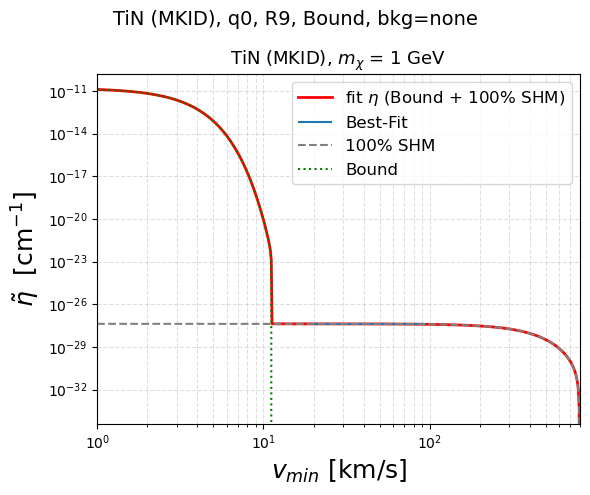

In [28]:
run_masses('TiN', q='0', nbins=9, eta='Bound', masses=('3',))

### Light mediator (q2), 9 energy bins

signal     : [34.5706271  46.00441225 55.300761   64.95009153 73.29779367 80.34635597
 86.95761825 92.95317059 97.76530251]
background : [0. 0. 0. 0. 0. 0. 0. 0. 0.]
saved /Users/koichiromacstudio/Documents/Claude/QuantumSensor/qsensor_analysis/results/MKID/bkg-none/TiN_q2_M3_R9_Bound/flux.pdf
TiN q2 M3 R9: 9 E-bins x 176 v_min bins, peak flux 8.34e+00


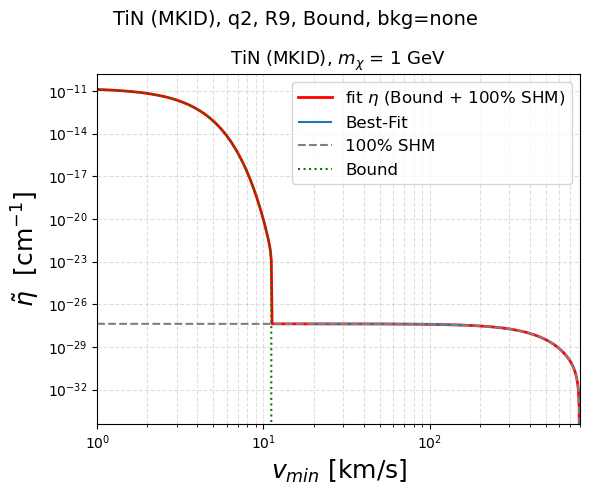

In [29]:
run_masses('TiN', q='2', nbins=9, eta='Bound', masses=('3',))